<div style="display: flex; align-items: center; justify-content: center; flex-wrap: wrap;">
    <div style="flex: 1; max-width: 400px; display: flex; justify-content: center;">
        <img src="https://magic.novaims.unl.pt/media/1tdf2arr/ims25_horizontal__positivo_rgb.svg" style="max-width: 70%; height: auto; margin-top: 50px; margin-bottom: 50px; margin-left: 6rem;">
    </div>
    <div style="flex: 2; text-align: center; margin-top: 20px; margin-left: 6rem;">
        <div style="font-size: 28px; font-weight: bold; line-height: 1.2;">
            <span style="color: #FFCD41;">Thesis Project |</span> <span style="color: #F58228;">LISBOA User Study Analysis</span>
        </div>
        <div style="font-size: 17px; font-weight: bold; margin-top: 10px;">2025 - 2026</div>
        <div style="font-size: 17px; font-weight: bold;">Master in Data Science and Advanced Analytics</div>
        <div style="margin-top: 20px;"><div>Andre Filipe Gomes Silvestre, 20240502</div><div style="margin-top: 6px; font-size: 14px;"><b>Supervisors:</b> Prof. Dr. Bruno Jardim; Prof. Dr. Miguel de Castro Neto</div></div>
    </div>
</div>

<style>
@import url('https://fonts.cdnfonts.com/css/avenir-next-lt-pro?styles=29974');
</style>

<div style="background: linear-gradient(to right, #F58228, #FFCD41); padding: 15px; color: white; border-radius: 300px; text-align: center;">
    <center><h1 style="margin-left: 100px; margin-top: 10px; margin-bottom: 4px; color: white; font-size: 32px; font-family: 'Avenir Next LT Pro', sans-serif;"><b>User Study Results Analysis</b></h1></center>
</div>

<br><br>

## **Notebook overview**

This notebook analyses the LISBOA user-study questionnaire exported from Microsoft Forms under `eval/results/`. It follows the same thesis-facing visual standard as the benchmark and ablation notebook, but keeps the user study methodologically separate: the study measures perceived usefulness, factual trust, response quality, personalization, interface quality, satisfaction, recommendation intent, and open-ended feedback.

### **What this notebook does**

1. Reads the raw XLSX and maps Microsoft Forms column labels to stable questionnaire item IDs (`U1` to `S1`).
2. Uses the real survey data when enough responses are available, or a synthetic preview sample when the current file is too small to validate plots.
3. Produces a reusable dimension-level results table with medians, IQRs, and valid participant counts.
4. Builds thesis-quality figures for Likert distributions, dimension profiles, task coverage, recommendation intent, correlations, and qualitative themes.
5. Keeps the interpretation conservative: Likert items are treated as ordinal, and the user study is formative human-centred evidence.

## **Evaluation scope and reading guide**

This notebook analyses the LISBOA user study as a human-centred complement to the automated benchmark and ablation protocols. Automated evaluation checks response quality against reference metadata and tool evidence; this analysis checks whether direct users perceive LISBOA as useful, trustworthy, clear, personalized, usable, and satisfactory after testing the prototype.

### **Interpretation notes**

- The planned sample is a convenience sample of about 10 to 15 participants, so results should not be written as population-level proof.
- The primary quantitative summaries are **median** and **interquartile range (IQR)** because the questionnaire uses 1 to 5 Likert responses.
- Synthetic preview data are generated only to validate notebook logic, charts, styling, and table formatting while the real XLSX contains too few rows.
- Open-text coding is a transparent first pass and still requires critical reading of the actual excerpts before reporting substantive interpretations.

In [1]:
# ===========================================================================
# Core setup
# ===========================================================================
# pip install pandas numpy matplotlib seaborn scipy openpyxl

from __future__ import annotations

import math
import re
import sys
import textwrap
import unicodedata
from collections import Counter
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib import font_manager
from matplotlib.axes import Axes
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.figure import Figure
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib.patches import FancyBboxPatch

try:
    from scipy.stats import spearmanr
except Exception:
    spearmanr = None

%matplotlib inline


def resolve_project_root() -> Path:
    """Resolve the repository root even when the notebook is opened from eval/."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "config.py").exists() and (candidate / "eval" / "results").exists():
            return candidate
    return Path.cwd()


def pick_plot_font() -> str:
    """Pick the closest available font to the thesis notebook style."""
    preferred_fonts = ["Borna", "Avenir Next LT Pro", "Avenir Next", "Arial", "DejaVu Sans"]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in preferred_fonts:
        if font_name in available_fonts:
            return font_name
    return "DejaVu Sans"


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EVAL_DIR = PROJECT_ROOT / "eval"
EVAL_RESULTS_DIR = EVAL_DIR / "results"
USER_STUDY_OUTPUT_DIR = EVAL_RESULTS_DIR / "user_study"
USER_STUDY_XLSX = EVAL_RESULTS_DIR / "LISBOA_Survey_Forms_06.06.2026.xlsx"
FIGURES_DIR = EVAL_RESULTS_DIR / "figures"
LISBOA_LOGO_PATH = PROJECT_ROOT / "img" / "Logo_1-1_WithoutBG.png"

RANDOM_SEED = 20240502
SYNTHETIC_PREVIEW_MODE = "auto"  # allowed: "auto", "always", "never"
SYNTHETIC_N = 24
MIN_REAL_RESPONSES_FOR_REAL_MODE = 8
EXPORT_MAIN_FIGURES = True
EXPORT_TABLES = True
EXPORT_DPI = 600

USER_STUDY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PLOT_FONT = pick_plot_font()

# Official LISBOA anchors from the app and benchmark notebook. The plotting
# palette below mutes those anchors for publication figures instead of using
# saturated red/yellow across every category.
BRAND_RED = "#ff4011"
BRAND_YELLOW = "#f6da00"
PRIMARY_RED = "#d9482a"
SECONDARY_ORANGE = "#d9853b"
ACCENT_YELLOW = "#e0c13b"
LISBOA_GOLD = "#c9a833"
OFF_WHITE = "#fffdf8"
WARM_CREAM = "#fff7dc"
LIGHT_GREY = "#e9edf2"
MID_GREY = "#c7cdd5"
NEUTRAL_GREY = "#8f969e"
DARK_GREY = "#20242a"
SOFT_PANEL = "#f8fafc"
SOFT_RED = "#bf5a46"
SOFT_SLATE = "#6f7d8b"
DEEP_SLATE = "#46515c"

PROJECT_PALETTE = [PRIMARY_RED, SECONDARY_ORANGE, LISBOA_GOLD, SOFT_SLATE]
PANEL_ACCENTS = [PRIMARY_RED, LISBOA_GOLD, SECONDARY_ORANGE, SOFT_RED]
QUALITATIVE_ACCENTS = {
    "Helpful aspects": LISBOA_GOLD,
    "Observed issues": SOFT_RED,
    "Improvement requests": SECONDARY_ORANGE,
}
LIKERT_PALETTE = {
    1: "#9f3f35",
    2: "#cf7f62",
    3: "#cbd3dc",
    4: "#e5ca70",
    5: "#b99b2f",
}
SCORE_CMAP = LinearSegmentedColormap.from_list(
    "lisboa_scores_academic",
    [OFF_WHITE, "#fff3cf", "#ead084", "#d99a54", PRIMARY_RED],
)
CORRELATION_CMAP = LinearSegmentedColormap.from_list(
    "lisboa_correlation_academic",
    ["#53697c", "#f7f2e8", "#b94f3e"],
)

sns.set_theme(
    context="paper",
    style="white",
    font=PLOT_FONT,
    rc={"figure.figsize": (16, 8)},
    font_scale=1.35,
)
sns.set_palette(PROJECT_PALETTE)
plt.rcParams["figure.figsize"] = (16, 8)
plt.rcParams["figure.dpi"] = 160
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11.5
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 9.5
plt.rcParams["ytick.labelsize"] = 9.5
plt.rcParams["legend.fontsize"] = 9.5
plt.rcParams["legend.title_fontsize"] = 9.5
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [PLOT_FONT, "Arial", "DejaVu Sans"]
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["grid.color"] = LIGHT_GREY
plt.rcParams["grid.alpha"] = 0.42
plt.rcParams["axes.edgecolor"] = DARK_GREY
plt.rcParams["text.color"] = DARK_GREY
plt.rcParams["axes.labelcolor"] = DARK_GREY
plt.rcParams["xtick.color"] = DARK_GREY
plt.rcParams["ytick.color"] = DARK_GREY
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print(f"Project root: {PROJECT_ROOT}")
print(f"User-study XLSX: {USER_STUDY_XLSX.relative_to(PROJECT_ROOT)}")
print(f"Output directory: {USER_STUDY_OUTPUT_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figures directory: {FIGURES_DIR.relative_to(PROJECT_ROOT)}")
print(f"LISBOA logo: {LISBOA_LOGO_PATH.relative_to(PROJECT_ROOT)}")
print(f"Synthetic preview mode: {SYNTHETIC_PREVIEW_MODE}")
print(f"Plot font: {PLOT_FONT}")

Project root: c:\Users\andre\OneDrive - NOVAIMS\[MDSAA-DS]_Thesis\LISBOA_MultiAgentSystem
User-study XLSX: eval\results\LISBOA_Survey_Forms_06.06.2026.xlsx
Output directory: eval\results\user_study
Figures directory: eval\results\figures
LISBOA logo: img\Logo_1-1_WithoutBG.png
Synthetic preview mode: auto
Plot font: Borna


In [2]:
# ===========================================================================
# Formatting, schema, and mapping helpers
# ===========================================================================
def normalise_text(value: Any) -> str:
    """Return an ASCII lowercase representation for robust column matching."""
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return ""
    text = str(value).replace("\xa0", " ").strip().lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(char for char in text if not unicodedata.combining(char))
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def clean_display_text(value: Any) -> str:
    """Clean questionnaire text while preserving readable display labels."""
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return ""
    text = str(value).replace("\xa0", " ").strip()
    text = re.sub(r"[\U00010000-\U0010ffff]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip(" ;")


def format_number(value: float | int | None, digits: int = 2) -> str:
    """Format numeric values for analysis tables."""
    if value is None or pd.isna(value):
        return "-"
    return f"{float(value):.{digits}f}"


def format_iqr(q1: float | None, q3: float | None) -> str:
    """Format an interquartile range as [Q1, Q3]."""
    if q1 is None or q3 is None or pd.isna(q1) or pd.isna(q3):
        return "-"
    return f"[{float(q1):.2f}, {float(q3):.2f}]"


def format_percent(value: float | int | None, digits: int = 1) -> str:
    """Format a fraction as a percentage string."""
    if value is None or pd.isna(value):
        return "-"
    return f"{100 * float(value):.{digits}f}%"


def style_axis(
    ax: Axes,
    title: str,
    xlabel: str,
    ylabel: str,
    *,
    rotate_xticks: int = 0,
    y_limits: tuple[float, float] | None = None,
    x_limits: tuple[float, float] | None = None,
    show_y_grid: bool = True,
    show_x_grid: bool = False,
) -> None:
    """Apply a consistent thesis-ready style to one matplotlib axis."""
    ax.set_facecolor("white")
    ax.set_title(title, fontsize=12.8, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, fontsize=9.6, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=9.6, fontweight="bold")
    if y_limits is not None:
        ax.set_ylim(*y_limits)
    if x_limits is not None:
        ax.set_xlim(*x_limits)
    ax.tick_params(axis="x", rotation=rotate_xticks)
    if show_y_grid:
        ax.grid(True, axis="y", linestyle="--", alpha=0.55, color=LIGHT_GREY)
    else:
        ax.grid(False, axis="y")
    if show_x_grid:
        ax.grid(True, axis="x", linestyle="--", alpha=0.55, color=LIGHT_GREY)
    else:
        ax.grid(False, axis="x")
    sns.despine(ax=ax, left=True, bottom=False)


def save_figure(name: str, fig: Figure | None = None) -> Path | None:
    """Export selected figures as SVG and high-resolution PNG."""
    if not EXPORT_MAIN_FIGURES:
        return None
    fig = fig or plt.gcf()
    fig.patch.set_facecolor("white")
    for axis in fig.axes:
        axis.set_facecolor("white")
    svg_path = FIGURES_DIR / f"{name}.svg"
    png_path = FIGURES_DIR / f"{name}.png"
    save_kwargs = {"bbox_inches": "tight", "facecolor": "white", "edgecolor": "none"}
    fig.savefig(svg_path, format="svg", **save_kwargs)
    fig.savefig(png_path, format="png", dpi=EXPORT_DPI, **save_kwargs)
    print(f"Exported: {svg_path.relative_to(PROJECT_ROOT)}")
    print(f"Exported: {png_path.relative_to(PROJECT_ROOT)}")
    return svg_path


def dataframe_to_markdown(df: pd.DataFrame) -> str:
    """Render a DataFrame as a Markdown table without optional dependencies."""
    columns = [str(column) for column in df.columns]
    rows = [[str(value) for value in row] for row in df.to_numpy()]
    widths = [len(column) for column in columns]
    for row in rows:
        widths = [max(width, len(value)) for width, value in zip(widths, row)]
    header = "| " + " | ".join(column.ljust(width) for column, width in zip(columns, widths)) + " |"
    divider = "| " + " | ".join("-" * width for width in widths) + " |"
    body = ["| " + " | ".join(value.ljust(width) for value, width in zip(row, widths)) + " |" for row in rows]
    return "\n".join([header, divider, *body])


def display_styled_table(
    df: pd.DataFrame,
    *,
    caption: str | None = None,
    gradient_subset: list[str] | None = None,
    precision: int = 2,
    vmin: float | None = None,
    vmax: float | None = None,
) -> None:
    """Display a compact styled table with optional score gradients."""
    if df.empty:
        display(Markdown("_No rows available._"))
        return
    styler = df.style.format(precision=precision)
    if caption:
        styler = styler.set_caption(caption)
    available_subset = [column for column in gradient_subset or [] if column in df.columns]
    if available_subset:
        styler = styler.background_gradient(cmap=SCORE_CMAP, subset=available_subset, vmin=vmin, vmax=vmax)
    styler = styler.set_table_styles(
        [
            {"selector": "caption", "props": "caption-side: top; font-weight: bold; color: #20242a; text-align: left;"},
            {"selector": "th", "props": "font-weight: bold; background-color: #fff7cc; color: #20242a;"},
            {"selector": "td", "props": "border-color: #e9edf2;"},
        ]
    )
    display(styler)


# ---------------------------------------------------------------------------
# Figure-level visual helpers aligned with benchmark/ablation styling
# ---------------------------------------------------------------------------
QUALITY_BAND_GREY = "#f1f3f6"
SOFT_PANEL_GREY = "#f8fafc"
ZERO_LINE_GREY = "#aeb7c2"
def get_user_study_mode_label() -> str:
    """Resolve the badge label at draw time using the current analysis mode."""
    mode = globals().get("analysis_mode")
    if mode == "synthetic_preview":
        return "Synthetic preview"
    if mode == "real":
        return "Real responses"
    return "Synthetic preview"


def hex_to_rgb(hex_color: str) -> np.ndarray:
    """Convert a hex colour to an RGB array in the 0-1 range."""
    clean = hex_color.strip().lstrip("#")
    return np.array([int(clean[index:index + 2], 16) / 255 for index in (0, 2, 4)])


def rgb_to_hex(rgb: np.ndarray) -> str:
    """Convert an RGB array in the 0-1 range to hex."""
    clipped = np.clip(rgb, 0, 1)
    return "#" + "".join(f"{int(round(channel * 255)):02x}" for channel in clipped)


def mix_hex(base_color: str, overlay_color: str = "#ffffff", overlay_weight: float = 0.50) -> str:
    """Mix two hex colours to create restrained tonal palettes."""
    base = hex_to_rgb(base_color)
    overlay = hex_to_rgb(overlay_color)
    return rgb_to_hex(base * (1 - overlay_weight) + overlay * overlay_weight)


def sequential_panel_colors(base_color: str, n: int, *, min_white: float = 0.16, max_white: float = 0.68) -> list[str]:
    """Build a one-hue sequence from light to strong for ordered bars."""
    if n <= 0:
        return []
    if n == 1:
        return [mix_hex(base_color, "#ffffff", 0.25)]
    weights = np.linspace(max_white, min_white, n)
    return [mix_hex(base_color, "#ffffff", float(weight)) for weight in weights]


def score_to_color(value: float, *, vmin: float = 1.0, vmax: float = 5.0) -> tuple[float, float, float, float]:
    """Map a Likert score to the restrained LISBOA score gradient."""
    if pd.isna(value):
        return (*hex_to_rgb(MID_GREY), 1.0)
    clipped = min(vmax, max(vmin, float(value)))
    return SCORE_CMAP((clipped - vmin) / (vmax - vmin))


def load_lisboa_logo() -> np.ndarray | None:
    """Load the LISBOA transparent-logo bitmap used in chart badges."""
    if LISBOA_LOGO_PATH.exists():
        return plt.imread(LISBOA_LOGO_PATH)
    return None


def add_figure_header(fig: Figure, title: str, subtitle: str) -> None:
    """Add the same top-left hierarchy used by the benchmark figures."""
    fig.text(
        0.042,
        0.955,
        title,
        ha="left",
        va="top",
        fontsize=18.4,
        fontweight="black",
        color=DARK_GREY,
    )
    fig.text(
        0.042,
        0.905,
        subtitle,
        ha="left",
        va="top",
        fontsize=9.4,
        color=NEUTRAL_GREY,
    )


def add_corner_logo(fig: Figure, *, x: float = 0.982, y: float = 0.945, zoom: float = 0.026) -> None:
    """Place a fixed-size LISBOA logo mark in the figure header."""
    logo = load_lisboa_logo()
    if logo is None:
        return
    image_box = OffsetImage(logo, zoom=zoom)
    annotation = AnnotationBbox(
        image_box,
        (x, y),
        xycoords=fig.transFigure,
        frameon=False,
        box_alignment=(1.0, 1.0),
        pad=0.0,
        zorder=30,
    )
    fig.add_artist(annotation)


def draw_lisboa_badge(ax: Axes, *, label: str = "User study", accent: str = PRIMARY_RED) -> None:
    """Draw a compact LISBOA badge matching the benchmark model badges."""
    ax.set_axis_off()
    badge = FancyBboxPatch(
        (0.030, 0.335),
        0.865,
        0.355,
        boxstyle="round,pad=0.012,rounding_size=0.040",
        transform=ax.transAxes,
        facecolor="white",
        edgecolor=LIGHT_GREY,
        linewidth=1.0,
        clip_on=False,
        zorder=8,
    )
    ax.add_patch(badge)
    ax.plot(
        [0.060, 0.060],
        [0.395, 0.630],
        transform=ax.transAxes,
        color=accent,
        linewidth=2.8,
        solid_capstyle="round",
        clip_on=False,
        zorder=9,
    )
    logo = load_lisboa_logo()
    if logo is not None:
        image_box = OffsetImage(logo, zoom=0.040)
        annotation = AnnotationBbox(
            image_box,
            (0.175, 0.515),
            xycoords=ax.transAxes,
            frameon=False,
            box_alignment=(0.5, 0.5),
            zorder=10,
        )
        ax.add_artist(annotation)
    ax.text(0.300, 0.580, "LISBOA", transform=ax.transAxes, fontsize=8.0, fontweight="bold", color=accent, ha="left", va="center", zorder=10)
    ax.text(0.300, 0.462, label, transform=ax.transAxes, fontsize=8.7, fontweight="bold", color=DARK_GREY, ha="left", va="center", zorder=10)


def round_bar_patches(ax: Axes, rounding_fraction: float = 0.22) -> None:
    """Replace rectangular bars with rounded patches, matching the benchmark figures."""
    original_patches = list(ax.patches)
    for patch in original_patches:
        if not patch.get_visible():
            continue
        width = float(patch.get_width())
        height = float(patch.get_height())
        if abs(width) < 1e-12 or abs(height) < 1e-12:
            continue

        x = float(patch.get_x())
        y = float(patch.get_y())
        x0 = min(x, x + width)
        y0 = min(y, y + height)
        abs_width = abs(width)
        abs_height = abs(height)
        rounding_size = max(min(abs_width, abs_height) * rounding_fraction, 0.01)

        rounded = FancyBboxPatch(
            (x0, y0),
            abs_width,
            abs_height,
            boxstyle=f"round,pad=0.0,rounding_size={rounding_size}",
            linewidth=patch.get_linewidth(),
            edgecolor=patch.get_edgecolor(),
            facecolor=patch.get_facecolor(),
            mutation_aspect=1,
            alpha=patch.get_alpha(),
            zorder=patch.get_zorder(),
        )
        ax.add_patch(rounded)
        patch.set_visible(False)


def wrap_labels(labels: list[str], width: int = 24) -> list[str]:
    """Wrap long categorical labels for compact horizontal bar panels."""
    return [textwrap.fill(str(label), width=width, break_long_words=False) for label in labels]


def label_horizontal_bars(
    ax: Axes,
    *,
    offset: float = 0.08,
    total: int | None = None,
    outside: bool = True,
) -> None:
    """Write count labels without placing them over bars or gridlines."""
    for patch in ax.patches:
        if not patch.get_visible():
            continue
        width = patch.get_width()
        if abs(width) < 1e-12:
            continue
        label = f"{int(round(width))}"
        if total and total > 0:
            label = f"{int(round(width))} ({width / total:.0%})"

        y_center = patch.get_y() + patch.get_height() / 2
        if outside:
            ax.text(
                1.012,
                y_center,
                label,
                transform=ax.get_yaxis_transform(),
                va="center",
                ha="left",
                fontsize=8.2,
                fontweight="bold",
                color=DARK_GREY,
                clip_on=False,
                bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.96, "pad": 0.8},
                zorder=8,
            )
            continue

        ax.text(
            width + offset,
            y_center,
            label,
            va="center",
            ha="left",
            fontsize=8.2,
            fontweight="bold",
            color=DARK_GREY,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.92, "pad": 0.6},
            zorder=8,
        )

LIKERT_SCORE_MAP = {
    "strongly disagree": 1,
    "disagree": 2,
    "neither agree nor disagree": 3,
    "neutral": 3,
    "agree": 4,
    "strongly agree": 5,
    "discordo totalmente": 1,
    "discordo": 2,
    "nem concordo nem discordo": 3,
    "concordo": 4,
    "concordo totalmente": 5,
    "very low": 1,
    "low": 2,
    "moderate": 3,
    "medium": 3,
    "high": 4,
    "very high": 5,
    "muito baixa": 1,
    "baixa": 2,
    "moderada": 3,
    "media": 3,
    "alta": 4,
    "muito alta": 5,
}
LIKERT_LABELS = {1: "Strongly disagree", 2: "Disagree", 3: "Neither agree nor disagree", 4: "Agree", 5: "Strongly agree"}
FAMILIARITY_LABELS = {1: "Very low", 2: "Low", 3: "Moderate", 4: "High", 5: "Very high"}

ITEM_METADATA = pd.DataFrame(
    [
        {"item_id": "U1", "dimension": "Usefulness", "short_label": "Useful", "question": "LISBOA was useful for the tasks I attempted."},
        {"item_id": "U2", "dimension": "Usefulness", "short_label": "Practical decisions", "question": "LISBOA helped me make practical Lisbon tourism or mobility decisions."},
        {"item_id": "T1", "dimension": "Trust", "short_label": "Grounded", "question": "The answers appeared grounded in specific Lisbon information rather than generic advice."},
        {"item_id": "T2", "dimension": "Trust", "short_label": "Uncertainty", "question": "LISBOA clearly signalled uncertainty, missing information, or scope limitations when relevant."},
        {"item_id": "R1", "dimension": "Response Quality", "short_label": "Clear", "question": "The answers were clear and easy to follow."},
        {"item_id": "R2", "dimension": "Response Quality", "short_label": "Right detail", "question": "The level of detail and structure matched my questions."},
        {"item_id": "P1", "dimension": "Personalization", "short_label": "Context combination", "question": "LISBOA combined relevant context when needed, such as weather, transport, places, events, or local information."},
        {"item_id": "P2", "dimension": "Personalization", "short_label": "Adapted", "question": "LISBOA adapted to preferences, constraints, or follow-up requests I provided."},
        {"item_id": "I1", "dimension": "Interface", "short_label": "Simple interface", "question": "The interface was simple to use."},
        {"item_id": "I2", "dimension": "Interface", "short_label": "Response time", "question": "The response time was acceptable for this type of prototype."},
        {"item_id": "S1", "dimension": "Overall Satisfaction", "short_label": "Satisfied", "question": "Overall, I am satisfied with the LISBOA experience."},
    ]
)
ITEM_IDS = ITEM_METADATA["item_id"].tolist()
DIMENSION_ORDER = ["Usefulness", "Trust", "Response Quality", "Personalization", "Interface", "Overall Satisfaction"]
DIMENSION_ITEMS = {dimension: group["item_id"].tolist() for dimension, group in ITEM_METADATA.groupby("dimension", sort=False)}

COLUMN_MATCHERS = {
    "id": ["id"],
    "started_at": ["hora de inicio", "start time"],
    "completed_at": ["hora de conclusao", "completion time", "completed"],
    "email": ["e mail", "email"],
    "name": ["nome", "name"],
    "consent": ["consent and eligibility"],
    "participant_type": ["which option best describes you"],
    "familiarity_lisbon": ["familiar with lisbon as a city"],
    "familiarity_ai": ["familiar with ai chatbots", "virtual assistants"],
    "testing_language": ["which language did you mainly use"],
    "tasks_completed": ["which tasks did you complete"],
    "U1": ["useful for the tasks"],
    "U2": ["practical lisbon tourism or mobility decisions"],
    "T1": ["grounded in specific lisbon information"],
    "T2": ["signalled uncertainty", "signaled uncertainty", "scope limitations"],
    "R1": ["clear and easy to follow"],
    "R2": ["level of detail and structure matched"],
    "P1": ["combined relevant context"],
    "P2": ["adapted to preferences constraints or follow up"],
    "I1": ["interface was simple to use"],
    "I2": ["response time was acceptable"],
    "S1": ["overall i am satisfied"],
    "recommend": ["would you recommend lisboa"],
    "helpful_text": ["most helpful part"],
    "issue_text": ["notice any incorrect unclear incomplete or risky"],
    "improve_text": ["what should be improved or added"],
}


def find_column(columns: list[str], patterns: list[str]) -> str | None:
    """Find the first column whose normalized label contains any pattern."""
    normalised_columns = {column: normalise_text(column) for column in columns}
    for pattern in patterns:
        normalised_pattern = normalise_text(pattern)
        for column, label in normalised_columns.items():
            if label == normalised_pattern or normalised_pattern in label:
                return column
    return None


def map_survey_columns(raw_frame: pd.DataFrame) -> tuple[dict[str, str], list[str]]:
    """Map raw Microsoft Forms columns to stable analysis field names."""
    columns = [str(column) for column in raw_frame.columns]
    mapping: dict[str, str] = {}
    missing: list[str] = []
    for field_name, patterns in COLUMN_MATCHERS.items():
        column = find_column(columns, patterns)
        if column is None:
            missing.append(field_name)
        else:
            mapping[field_name] = column
    return mapping, missing


def coerce_likert(value: Any) -> float:
    """Convert Likert text or numeric values to a 1 to 5 score."""
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return np.nan
    if isinstance(value, (int, float)) and not isinstance(value, bool):
        return float(value) if 1 <= float(value) <= 5 else np.nan
    label = normalise_text(value)
    if not label:
        return np.nan
    if label in LIKERT_SCORE_MAP:
        return float(LIKERT_SCORE_MAP[label])
    numeric_match = re.search(r"\b([1-5])\b", label)
    return float(numeric_match.group(1)) if numeric_match else np.nan


def safe_column(raw_frame: pd.DataFrame, mapping: dict[str, str], field_name: str) -> pd.Series:
    """Return a mapped raw column or an empty Series with matching index."""
    column = mapping.get(field_name)
    if column is None:
        return pd.Series([np.nan] * len(raw_frame), index=raw_frame.index)
    return raw_frame[column]


def recode_task_label(value: str) -> str:
    """Map raw task labels to compact analysis categories."""
    label = normalise_text(value)
    if "weather" in label or "tempo" in label or "clima" in label or "meteorologia" in label:
        return "Weather-aware"
    if "mobility" in label or "transport" in label or "mobilidade" in label or "transporte" in label:
        return "Mobility"
    if "tourism" in label or "local information" in label or "turismo" in label or "informacao local" in label or "event" in label or "evento" in label:
        return "Tourism/local info"
    if "itinerary" in label or "planning" in label or "itinerario" in label or "roteiro" in label or "planeamento" in label:
        return "Itinerary planning"
    if "other" in label:
        return "Other"
    return clean_display_text(value) or "Other"


def parse_tasks(value: Any) -> list[str]:
    """Parse Microsoft Forms semicolon-delimited task selections."""
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return []
    parts = [part.strip() for part in str(value).split(";") if part.strip()]
    return [recode_task_label(part) for part in parts]

In [3]:
# ===========================================================================
# Raw data loading, synthetic preview, and normalization
# ===========================================================================
if not USER_STUDY_XLSX.exists():
    raise FileNotFoundError(f"User-study XLSX not found: {USER_STUDY_XLSX}")

raw_real_df = pd.read_excel(USER_STUDY_XLSX)
real_column_map, missing_real_fields = map_survey_columns(raw_real_df)


def generate_synthetic_raw_responses(template_columns: list[str], column_map: dict[str, str], *, n: int, seed: int) -> pd.DataFrame:
    """Generate Microsoft Forms-like synthetic rows for previewing the analysis."""
    rng = np.random.default_rng(seed)
    rows: list[dict[str, Any]] = []
    participant_types = [
        "Lisbon resident",
        "Resident in Portugal, but not in Lisbon",
        "Tourist or visitor currently in Lisbon",
        "Prospective tourist or visitor planning a Lisbon trip",
    ]
    language_options = ["Portuguese", "English", "Both English and Portuguese"]
    task_options = ["Weather-aware question", "Mobility question", "Tourism or local information question", "Itinerary planning question"]
    helpful_texts = [
        "Transport guidance was the most useful part, especially when it named operators and practical stops.",
        "The weather-aware suggestions helped me decide whether an outdoor plan made sense.",
        "The answer structure made the itinerary easier to follow than a generic chatbot response.",
        "Local Lisbon context and source-grounded details were the most helpful parts.",
        "The bilingual interaction and clear formatting made the prototype easy to test.",
    ]
    issue_texts = [
        "Some transport alternatives were missing when a slightly longer walk would make another route useful.",
        "Location resolution failed for lesser-known places and local businesses.",
        "Long multi-stop itineraries sometimes became geographically incoherent.",
        "A few answers needed clearer uncertainty about missing schedules or unavailable coverage.",
        "No major issue, but response time can still feel slow for quick mobility questions.",
    ]
    improvement_texts = [
        "Improve route ordering and include transport between every itinerary stop.",
        "Add map links, stop names, estimated duration, and next departure information.",
        "Improve coverage for restaurants, local businesses, and less famous venues.",
        "Make long itineraries more compact with clearer sections and timings.",
        "Add accessibility, booking links, and stronger event filtering.",
    ]
    item_probabilities = {
        "U1": [0.02, 0.06, 0.14, 0.42, 0.36],
        "U2": [0.03, 0.09, 0.18, 0.42, 0.28],
        "T1": [0.01, 0.05, 0.10, 0.36, 0.48],
        "T2": [0.03, 0.08, 0.19, 0.40, 0.30],
        "R1": [0.01, 0.04, 0.12, 0.43, 0.40],
        "R2": [0.02, 0.08, 0.16, 0.42, 0.32],
        "P1": [0.02, 0.05, 0.12, 0.38, 0.43],
        "P2": [0.05, 0.10, 0.20, 0.40, 0.25],
        "I1": [0.03, 0.06, 0.16, 0.45, 0.30],
        "I2": [0.04, 0.10, 0.22, 0.40, 0.24],
        "S1": [0.02, 0.07, 0.18, 0.43, 0.30],
    }
    for index in range(n):
        row = {column: np.nan for column in template_columns}
        start = pd.Timestamp("2026-05-18 09:00:00") + pd.Timedelta(minutes=int(index * 41 + rng.integers(0, 20)))
        values = {
            "id": index + 1,
            "started_at": start,
            "completed_at": start + pd.Timedelta(minutes=int(rng.integers(10, 36))),
            "email": "synthetic_preview@example.invalid",
            "name": np.nan,
            "consent": "Please confirm your consent and eligibility.",
            "participant_type": rng.choice(participant_types, p=[0.35, 0.20, 0.20, 0.25]),
            "familiarity_lisbon": FAMILIARITY_LABELS[int(rng.choice([2, 3, 4, 5], p=[0.10, 0.25, 0.40, 0.25]))],
            "familiarity_ai": FAMILIARITY_LABELS[int(rng.choice([2, 3, 4, 5], p=[0.05, 0.20, 0.43, 0.32]))],
            "testing_language": rng.choice(language_options, p=[0.45, 0.35, 0.20]),
            "recommend": rng.choice(["Yes", "Maybe", "No"], p=[0.66, 0.29, 0.05]),
            "helpful_text": rng.choice(helpful_texts),
            "issue_text": rng.choice(issue_texts),
            "improve_text": rng.choice(improvement_texts),
        }
        task_count = int(rng.choice([2, 3, 4], p=[0.20, 0.45, 0.35]))
        values["tasks_completed"] = ";".join(rng.choice(task_options, size=task_count, replace=False).tolist())
        for item_id in ITEM_IDS:
            score = int(rng.choice([1, 2, 3, 4, 5], p=item_probabilities[item_id]))
            values[item_id] = LIKERT_LABELS[score]
        for field_name, value in values.items():
            column = column_map.get(field_name)
            if column is not None:
                row[column] = value
        rows.append(row)
    return pd.DataFrame(rows, columns=template_columns)


def normalize_survey(raw_frame: pd.DataFrame, column_map: dict[str, str]) -> pd.DataFrame:
    """Convert raw survey columns into a stable participant-level analysis table."""
    normalized = pd.DataFrame(index=raw_frame.index)
    normalized["participant_id"] = safe_column(raw_frame, column_map, "id").fillna(pd.Series(range(1, len(raw_frame) + 1), index=raw_frame.index))
    normalized["started_at"] = pd.to_datetime(safe_column(raw_frame, column_map, "started_at"), errors="coerce")
    normalized["completed_at"] = pd.to_datetime(safe_column(raw_frame, column_map, "completed_at"), errors="coerce")
    normalized["duration_minutes"] = (normalized["completed_at"] - normalized["started_at"]).dt.total_seconds() / 60
    normalized["participant_type"] = safe_column(raw_frame, column_map, "participant_type").apply(clean_display_text)
    normalized["testing_language"] = safe_column(raw_frame, column_map, "testing_language").apply(clean_display_text)
    normalized["tasks_completed"] = safe_column(raw_frame, column_map, "tasks_completed").apply(parse_tasks)
    normalized["task_count"] = normalized["tasks_completed"].apply(len)
    normalized["recommend"] = safe_column(raw_frame, column_map, "recommend").apply(clean_display_text)
    normalized["helpful_text"] = safe_column(raw_frame, column_map, "helpful_text").apply(clean_display_text)
    normalized["issue_text"] = safe_column(raw_frame, column_map, "issue_text").apply(clean_display_text)
    normalized["improve_text"] = safe_column(raw_frame, column_map, "improve_text").apply(clean_display_text)
    normalized["familiarity_lisbon"] = safe_column(raw_frame, column_map, "familiarity_lisbon").apply(coerce_likert)
    normalized["familiarity_ai"] = safe_column(raw_frame, column_map, "familiarity_ai").apply(coerce_likert)
    for item_id in ITEM_IDS:
        normalized[item_id] = safe_column(raw_frame, column_map, item_id).apply(coerce_likert)
    normalized["valid_item_count"] = normalized[ITEM_IDS].notna().sum(axis=1)
    return normalized.reset_index(drop=True)


raw_real_response_count = int(len(raw_real_df))
use_synthetic_preview = (
    SYNTHETIC_PREVIEW_MODE == "always"
    or (SYNTHETIC_PREVIEW_MODE == "auto" and raw_real_response_count < MIN_REAL_RESPONSES_FOR_REAL_MODE)
)
if SYNTHETIC_PREVIEW_MODE == "never":
    use_synthetic_preview = False

if use_synthetic_preview:
    raw_analysis_df = generate_synthetic_raw_responses(
        [str(column) for column in raw_real_df.columns],
        real_column_map,
        n=max(SYNTHETIC_N, MIN_REAL_RESPONSES_FOR_REAL_MODE),
        seed=RANDOM_SEED,
    )
    analysis_mode = "synthetic_preview"
else:
    raw_analysis_df = raw_real_df.copy()
    analysis_mode = "real"

analysis_column_map, missing_analysis_fields = map_survey_columns(raw_analysis_df)
real_df = normalize_survey(raw_real_df, real_column_map)
analysis_df = normalize_survey(raw_analysis_df, analysis_column_map)
analysis_df["analysis_mode"] = analysis_mode

schema_audit = pd.DataFrame(
    [
        {"Field": field_name, "Mapped raw column": analysis_column_map.get(field_name, "MISSING"), "Missing": field_name in missing_analysis_fields}
        for field_name in COLUMN_MATCHERS
    ]
)
safe_preview_columns = ["participant_id", "participant_type", "testing_language", "task_count", "familiarity_lisbon", "familiarity_ai", *ITEM_IDS, "recommend", "duration_minutes"]

display(Markdown("### Raw data status"))
display(
    pd.DataFrame(
        [
            {
                "Raw XLSX rows": len(raw_real_df),
                "Real response count": raw_real_response_count,
                "Analysis rows": len(raw_analysis_df),
                "Analysis mode": analysis_mode,
                "Missing mapped fields": ", ".join(missing_analysis_fields) if missing_analysis_fields else "None",
            }
        ]
    )
)
if analysis_mode == "synthetic_preview":
    display(Markdown("**Synthetic preview active.** The current XLSX has too few real responses for meaningful plots. Synthetic rows exist only inside this notebook run to validate tables, charts, and code paths. Do not interpret preview numbers as empirical findings."))

display(Markdown("### Column mapping audit"))
display(schema_audit)
display(Markdown("### Normalized analysis preview"))
display(analysis_df[safe_preview_columns].head(8).round(2))
display(Markdown("### Current real response snapshot"))
display(real_df[safe_preview_columns].head(5).round(2))

### Raw data status

,Raw XLSX rows,Real response count,Analysis rows,Analysis mode,Missing mapped fields
0,20,20,20,real,None


### Column mapping audit

,Field,Mapped raw column,Missing
0,id,Id,False
1,started_at,Hora de início,False
2,completed_at,Hora de conclusão,False
3,email,E-mail,False
4,name,Nome,False
5,consent,Consent and Eligibility\n,False
6,participant_type,👤 Participant Context\nWhich option best descr...,False
7,familiarity_lisbon,🧩 Prior Familiarity\nPlease rate your familiar...,False
8,familiarity_ai,🧩 Prior Familiarity\nPlease rate your familiar...,False
9,testing_language,🌐 Testing Language\nWhich language did you mai...,False


### Normalized analysis preview

,participant_id,participant_type,testing_language,task_count,familiarity_lisbon,familiarity_ai,U1,U2,T1,T2,R1,R2,P1,P2,I1,I2,S1,recommend,duration_minutes
0,3,Lisbon resident,Portuguese,4,5.0,5.0,3.0,3.0,5.0,5.0,5.0,5.0,5.0,5.0,3.0,5.0,4.0,Maybe,31.77
1,4,"Resident in Portugal, but not in Lisbon",Portuguese,4,4.0,1.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,5.0,5.0,Yes,12.33
2,5,"Resident in Portugal, but not in Lisbon",Portuguese,4,3.0,1.0,5.0,5.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,Yes,11.43
3,6,"Resident in Portugal, but not in Lisbon",Portuguese,4,3.0,4.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,Yes,9.98
4,7,"Resident in Portugal, but not in Lisbon",Portuguese,4,3.0,4.0,5.0,4.0,5.0,3.0,4.0,5.0,4.0,3.0,5.0,2.0,5.0,Yes,31.82
5,8,"Resident in Portugal, but not in Lisbon",Portuguese,1,3.0,1.0,5.0,4.0,4.0,2.0,4.0,5.0,4.0,3.0,5.0,4.0,4.0,Maybe,19.33
6,9,"Resident in Portugal, but not in Lisbon",Portuguese,1,4.0,4.0,4.0,3.0,3.0,3.0,5.0,3.0,4.0,4.0,5.0,4.0,4.0,Yes,5.65
7,10,"Resident in Portugal, but not in Lisbon",Portuguese,2,3.0,4.0,5.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,5.0,3.0,4.0,Yes,2.62


### Current real response snapshot

,participant_id,participant_type,testing_language,task_count,familiarity_lisbon,familiarity_ai,U1,U2,T1,T2,R1,R2,P1,P2,I1,I2,S1,recommend,duration_minutes
0,3,Lisbon resident,Portuguese,4,5.0,5.0,3.0,3.0,5.0,5.0,5.0,5.0,5.0,5.0,3.0,5.0,4.0,Maybe,31.77
1,4,"Resident in Portugal, but not in Lisbon",Portuguese,4,4.0,1.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,5.0,5.0,Yes,12.33
2,5,"Resident in Portugal, but not in Lisbon",Portuguese,4,3.0,1.0,5.0,5.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,Yes,11.43
3,6,"Resident in Portugal, but not in Lisbon",Portuguese,4,3.0,4.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,Yes,9.98
4,7,"Resident in Portugal, but not in Lisbon",Portuguese,4,3.0,4.0,5.0,4.0,5.0,3.0,4.0,5.0,4.0,3.0,5.0,2.0,5.0,Yes,31.82


## **Quantitative summaries**

This section builds the core participant-level summaries for the user study. For each participant, the notebook first computes the median of the items belonging to each dimension, then reports the median and IQR across participants.

This keeps the analysis aligned with the ordinal nature of Likert responses: medians and IQRs are the defensible primary summaries. Means and standard deviations are retained only as secondary diagnostics.

In [4]:
# ===========================================================================
# Item-level and dimension-level summaries
# ===========================================================================
def summarize_scores(values: pd.Series) -> dict[str, Any]:
    """Summarize one ordinal score vector with conservative descriptive statistics."""
    clean = pd.to_numeric(values, errors="coerce").dropna()
    if clean.empty:
        return {"n": 0, "median": np.nan, "q1": np.nan, "q3": np.nan, "iqr": np.nan, "mean": np.nan, "sd": np.nan, "positive_rate": np.nan, "top_box_rate": np.nan, "low_rate": np.nan}
    q1 = float(clean.quantile(0.25))
    q3 = float(clean.quantile(0.75))
    return {
        "n": int(clean.shape[0]),
        "median": float(clean.median()),
        "q1": q1,
        "q3": q3,
        "iqr": q3 - q1,
        "mean": float(clean.mean()),
        "sd": float(clean.std(ddof=1)) if len(clean) > 1 else 0.0,
        "positive_rate": float((clean >= 4).mean()),
        "top_box_rate": float((clean == 5).mean()),
        "low_rate": float((clean <= 2).mean()),
    }


item_long = analysis_df.melt(id_vars=["participant_id", "analysis_mode"], value_vars=ITEM_IDS, var_name="item_id", value_name="score").merge(ITEM_METADATA, on="item_id", how="left")
item_long["score_label"] = item_long["score"].map(LIKERT_LABELS)
item_long["dimension"] = pd.Categorical(item_long["dimension"], categories=DIMENSION_ORDER, ordered=True)

item_summary_rows = []
for _, metadata in ITEM_METADATA.iterrows():
    summary = summarize_scores(analysis_df[metadata["item_id"]])
    item_summary_rows.append(
        {
            "Dimension": metadata["dimension"],
            "Item": metadata["item_id"],
            "Short label": metadata["short_label"],
            "n": summary["n"],
            "Median": summary["median"],
            "IQR": summary["iqr"],
            "Mean": summary["mean"],
            "Positive (%)": 100 * summary["positive_rate"] if not pd.isna(summary["positive_rate"]) else np.nan,
            "Top box (%)": 100 * summary["top_box_rate"] if not pd.isna(summary["top_box_rate"]) else np.nan,
            "Low (%)": 100 * summary["low_rate"] if not pd.isna(summary["low_rate"]) else np.nan,
        }
    )
item_summary = pd.DataFrame(item_summary_rows)
item_summary["Dimension"] = pd.Categorical(item_summary["Dimension"], categories=DIMENSION_ORDER, ordered=True)
item_summary = item_summary.sort_values(["Dimension", "Item"]).reset_index(drop=True)

participant_dimension_rows = []
for _, row in analysis_df.iterrows():
    for dimension in DIMENSION_ORDER:
        item_ids = DIMENSION_ITEMS[dimension]
        scores = pd.to_numeric(row[item_ids], errors="coerce").dropna()
        participant_dimension_rows.append(
            {"participant_id": row["participant_id"], "dimension": dimension, "dimension_score": float(scores.median()) if len(scores) else np.nan, "items_answered": int(len(scores))}
        )
participant_dimension_scores = pd.DataFrame(participant_dimension_rows)
participant_dimension_scores["dimension"] = pd.Categorical(participant_dimension_scores["dimension"], categories=DIMENSION_ORDER, ordered=True)

dimension_summary_rows = []
for dimension in DIMENSION_ORDER:
    values = participant_dimension_scores.loc[participant_dimension_scores["dimension"] == dimension, "dimension_score"]
    summary = summarize_scores(values)
    dimension_summary_rows.append(
        {
            "Dimension": dimension,
            "Questions": "; ".join(DIMENSION_ITEMS[dimension]),
            "n": summary["n"],
            "Median": summary["median"],
            "Q1": summary["q1"],
            "Q3": summary["q3"],
            "IQR": summary["iqr"],
            "Mean": summary["mean"],
            "SD": summary["sd"],
            "Positive (%)": 100 * summary["positive_rate"] if not pd.isna(summary["positive_rate"]) else np.nan,
            "Top box (%)": 100 * summary["top_box_rate"] if not pd.isna(summary["top_box_rate"]) else np.nan,
            "Low (%)": 100 * summary["low_rate"] if not pd.isna(summary["low_rate"]) else np.nan,
        }
    )
dimension_summary = pd.DataFrame(dimension_summary_rows)
dimension_summary["Dimension"] = pd.Categorical(dimension_summary["Dimension"], categories=DIMENSION_ORDER, ordered=True)
dimension_summary = dimension_summary.sort_values("Dimension").reset_index(drop=True)

dimension_results_table = dimension_summary[["Dimension", "Questions", "Median", "Q1", "Q3", "n"]].copy()
dimension_results_table["Median"] = dimension_results_table["Median"].map(lambda value: format_number(value, 2))
dimension_results_table["IQR"] = dimension_results_table.apply(lambda row: format_iqr(row["Q1"], row["Q3"]), axis=1)
dimension_results_table = dimension_results_table[["Dimension", "Questions", "Median", "IQR", "n"]]
dimension_results_table["n"] = dimension_results_table["n"].astype(int)
dimension_results_markdown = dataframe_to_markdown(dimension_results_table)

display(Markdown("### User-study summary by evaluation dimension"))
display(dimension_results_table)
display(Markdown("### Markdown export"))
display(Markdown(f"```markdown\n{dimension_results_markdown}\n```"))

display(Markdown("### Extended dimension diagnostics"))
display_styled_table(
    dimension_summary[["Dimension", "Questions", "n", "Median", "IQR", "Mean", "SD", "Positive (%)", "Top box (%)", "Low (%)"]],
    caption="Participant-level dimension summaries. Positive means score >= 4; top box means score = 5.",
    gradient_subset=["Median", "Mean", "Positive (%)", "Top box (%)"],
    precision=2,
    vmin=1.0,
    vmax=5.0,
)
display(Markdown("### Item-level diagnostics"))
display_styled_table(
    item_summary,
    caption="Item-level distributions used to diagnose which question drives each dimension.",
    gradient_subset=["Median", "Mean", "Positive (%)", "Top box (%)"],
    precision=2,
    vmin=1.0,
    vmax=5.0,
)

### User-study summary by evaluation dimension

,Dimension,Questions,Median,IQR,n
0,Usefulness,U1; U2,4.50,"[3.88, 5.00]",20
1,Trust,T1; T2,4.00,"[3.50, 5.00]",20
2,Response Quality,R1; R2,4.50,"[4.00, 5.00]",20
3,Personalization,P1; P2,4.00,"[4.00, 5.00]",20
4,Interface,I1; I2,4.50,"[4.00, 5.00]",20
5,Overall Satisfaction,S1,4.00,"[4.00, 5.00]",20


### Markdown export

```markdown
| Dimension            | Questions | Median | IQR          | n  |
| -------------------- | --------- | ------ | ------------ | -- |
| Usefulness           | U1; U2    | 4.50   | [3.88, 5.00] | 20 |
| Trust                | T1; T2    | 4.00   | [3.50, 5.00] | 20 |
| Response Quality     | R1; R2    | 4.50   | [4.00, 5.00] | 20 |
| Personalization      | P1; P2    | 4.00   | [4.00, 5.00] | 20 |
| Interface            | I1; I2    | 4.50   | [4.00, 5.00] | 20 |
| Overall Satisfaction | S1        | 4.00   | [4.00, 5.00] | 20 |
```

### Extended dimension diagnostics

,Dimension,Questions,n,Median,IQR,Mean,SD,Positive (%),Top box (%),Low (%)
0,Usefulness,U1; U2,20,4.50,1.12,4.22,0.72,75.00,30.00,0.00
1,Trust,T1; T2,20,4.00,1.50,4.05,0.83,60.00,30.00,0.00
2,Response Quality,R1; R2,20,4.50,1.00,4.42,0.65,90.00,45.00,0.00
3,Personalization,P1; P2,20,4.00,1.00,4.25,0.75,80.00,40.00,0.00
4,Interface,I1; I2,20,4.50,1.00,4.40,0.64,80.00,40.00,0.00
5,Overall Satisfaction,S1,20,4.00,1.00,4.40,0.50,100.00,40.00,0.00


### Item-level diagnostics

,Dimension,Item,Short label,n,Median,IQR,Mean,Positive (%),Top box (%),Low (%)
0,Usefulness,U1,Useful,20,5.00,1.00,4.45,85.00,60.00,0.00
1,Usefulness,U2,Practical decisions,20,4.00,2.00,4.00,70.00,30.00,0.00
2,Trust,T1,Grounded,20,5.00,1.00,4.40,80.00,60.00,0.00
3,Trust,T2,Uncertainty,20,4.00,2.00,3.70,55.00,30.00,15.00
4,Response Quality,R1,Clear,20,5.00,1.00,4.50,95.00,55.00,0.00
5,Response Quality,R2,Right detail,20,5.00,1.00,4.35,85.00,55.00,5.00
6,Personalization,P1,Context combination,20,5.00,1.00,4.45,90.00,60.00,5.00
7,Personalization,P2,Adapted,20,4.00,2.00,4.05,65.00,40.00,0.00
8,Interface,I1,Simple interface,20,5.00,0.25,4.70,95.00,75.00,0.00
9,Interface,I2,Response time,20,4.50,1.25,4.10,75.00,50.00,10.00


## **Quantitative visuals**

The figures below answer different analytical questions. The dimension profile summarises perceived quality across evaluation dimensions; the Likert distribution checks whether medians hide disagreement; the context and task plots show whether participants exercised the intended use cases and whether the sample is balanced enough for interpretation.

Exported: eval\results\figures\user_study_dimension_profile.svg
Exported: eval\results\figures\user_study_dimension_profile.png


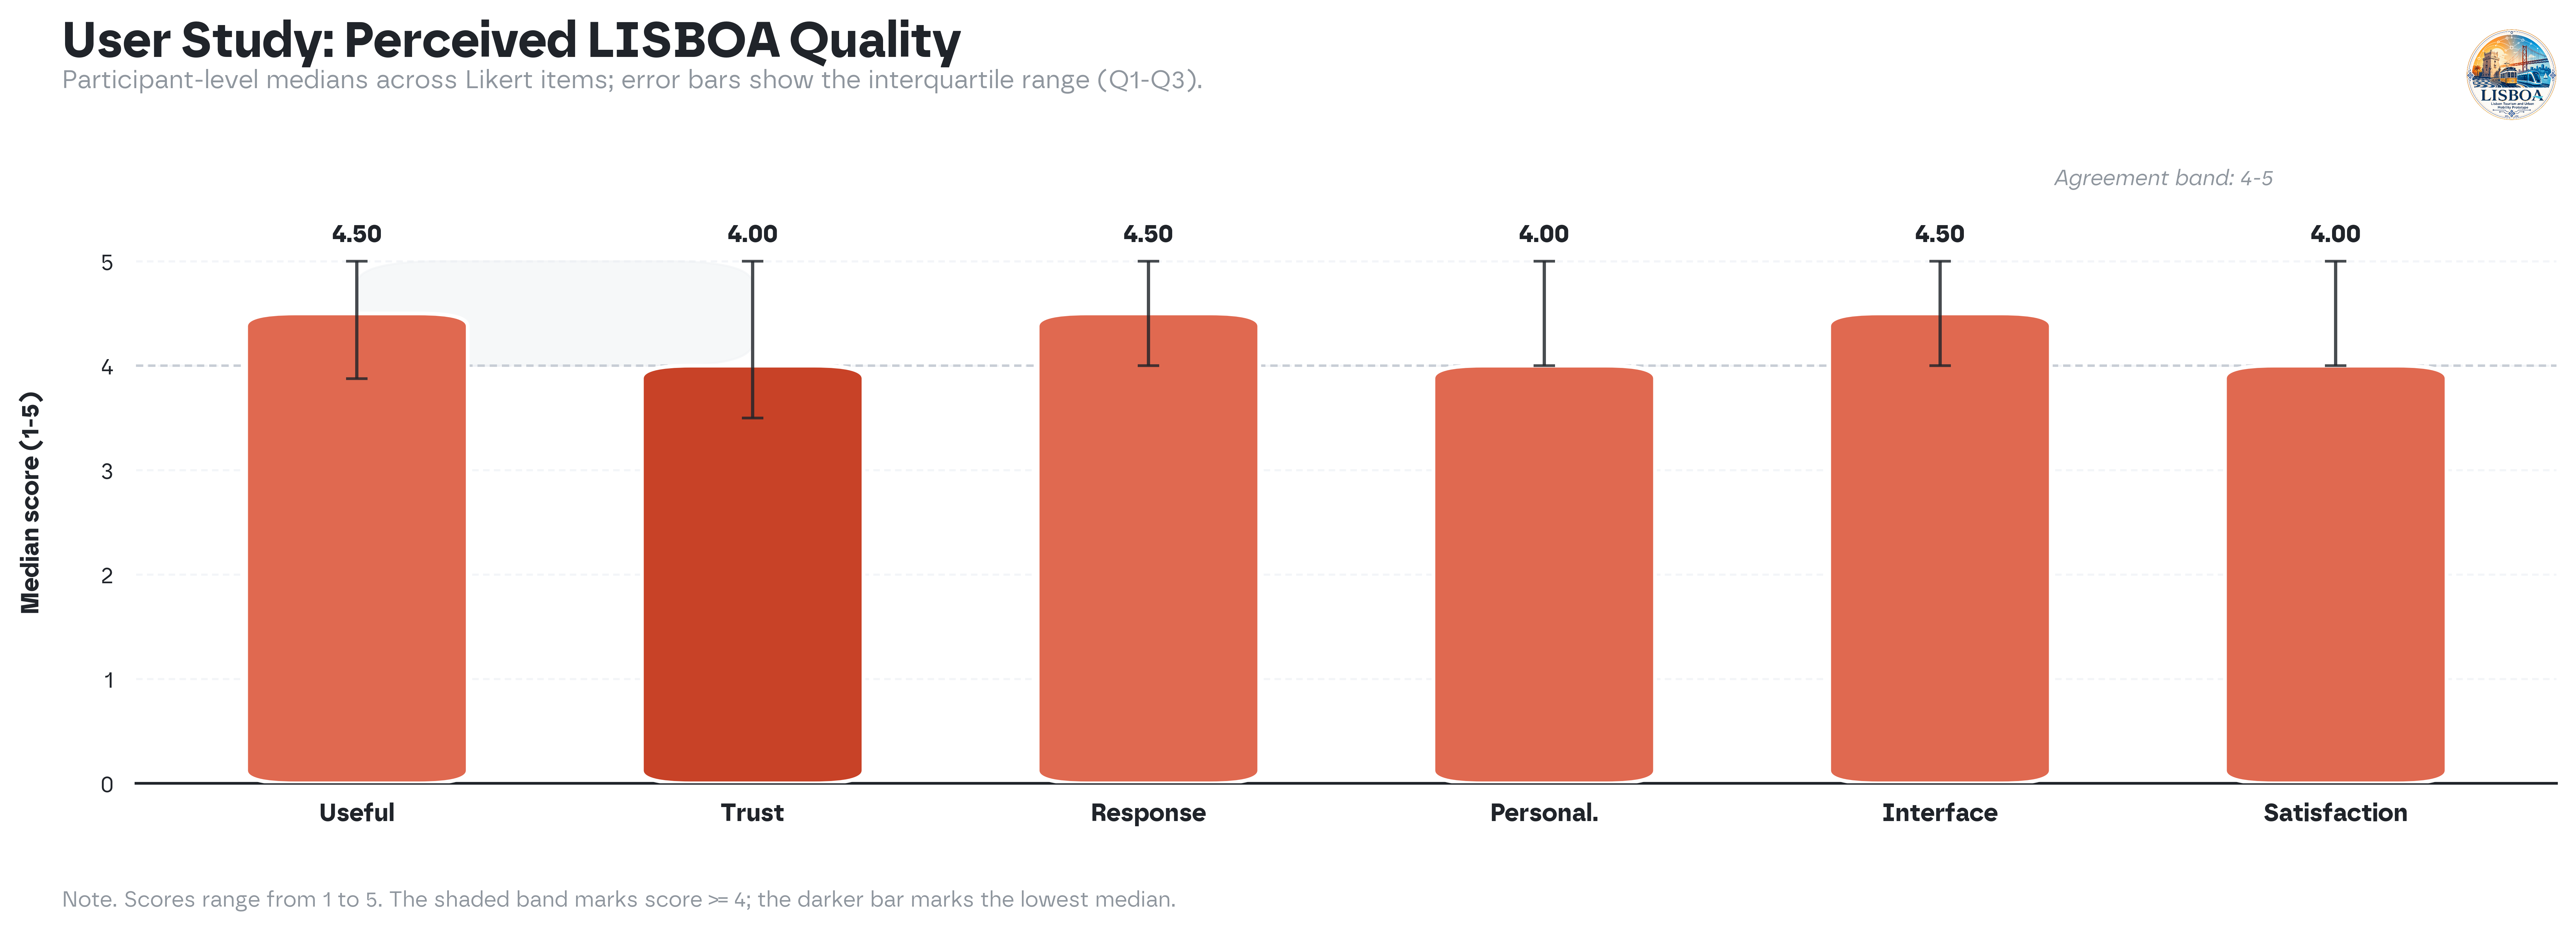

In [5]:
# ===========================================================================
# Figure 1: perceived-quality profile
# ===========================================================================
DIMENSION_SHORT_LABELS = {
    "Usefulness": "Useful",
    "Trust": "Trust",
    "Response Quality": "Response",
    "Personalization": "Personal.",
    "Interface": "Interface",
    "Overall Satisfaction": "Satisfaction",
}


def plot_dimension_profile(summary: pd.DataFrame, participant_scores: pd.DataFrame) -> Figure:
    """Plot median dimension scores with IQR and restrained LISBOA styling."""
    plot_summary = summary.copy()
    plot_summary["Dimension"] = pd.Categorical(plot_summary["Dimension"], categories=DIMENSION_ORDER, ordered=True)
    plot_summary = plot_summary.sort_values("Dimension").reset_index(drop=True)
    plot_summary["Short"] = plot_summary["Dimension"].map(DIMENSION_SHORT_LABELS)

    fig, score_axis = plt.subplots(figsize=(13.6, 5.05), dpi=EXPORT_DPI, facecolor="white")
    x_positions = np.arange(len(plot_summary))
    medians = plot_summary["Median"].astype(float).values
    q1s = plot_summary["Q1"].astype(float).values
    q3s = plot_summary["Q3"].astype(float).values
    lower_errors = np.clip(medians - q1s, 0, None)
    upper_errors = np.clip(q3s - medians, 0, None)

    base_bar = mix_hex(PRIMARY_RED, "#ffffff", 0.18)
    weakest_bar = mix_hex(PRIMARY_RED, "#000000", 0.08)
    weakest_idx = int(np.nanargmin(medians))
    bar_colors = [base_bar] * len(plot_summary)
    bar_colors[weakest_idx] = weakest_bar

    score_axis.axhspan(4.0, 5.0, color=QUALITY_BAND_GREY, alpha=0.58, zorder=0)
    score_axis.axhline(4.0, color=MID_GREY, linewidth=0.9, linestyle=(0, (3, 2)), zorder=1)
    score_axis.bar(
        x_positions,
        medians,
        yerr=np.vstack([lower_errors, upper_errors]),
        capsize=4.0,
        color=bar_colors,
        edgecolor="white",
        linewidth=1.4,
        width=0.56,
        error_kw={"elinewidth": 1.20, "ecolor": DARK_GREY, "alpha": 0.82},
        zorder=3,
    )
    round_bar_patches(score_axis, rounding_fraction=0.22)

    for x, median, upper_error in zip(x_positions, medians, upper_errors):
        label_y = min(5.18, float(median) + float(upper_error) + 0.13)
        score_axis.text(
            x,
            label_y,
            f"{median:.2f}",
            ha="center",
            va="bottom",
            fontsize=9.6,
            fontweight="bold",
            color=DARK_GREY,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.92, "pad": 1.0},
            zorder=6,
        )

    score_axis.set_xticks(x_positions)
    score_axis.set_xticklabels(plot_summary["Short"], rotation=0, fontsize=9.2, fontweight="bold")
    score_axis.set_ylabel("Median score (1-5)", fontsize=9.2, fontweight="bold")
    score_axis.yaxis.set_label_coords(-0.038, 0.50)
    score_axis.set_ylim(0, 5.38)
    score_axis.set_yticks([0, 1, 2, 3, 4, 5])
    score_axis.tick_params(axis="y", labelsize=8.6)
    score_axis.tick_params(axis="x", length=0, pad=7)
    score_axis.grid(True, axis="y", linestyle=(0, (3, 2)), alpha=0.52, color=LIGHT_GREY)
    sns.despine(ax=score_axis, left=True, bottom=False)

    subtitle = "Participant-level medians across Likert items; error bars show the interquartile range (Q1-Q3)."
    if analysis_mode == "synthetic_preview":
        subtitle += " Synthetic preview, not empirical findings."
    add_figure_header(fig, "User Study: Perceived LISBOA Quality", subtitle)
    add_corner_logo(fig)
    fig.text(0.875, 0.782, "Agreement band: 4-5", ha="right", va="bottom", fontsize=8.0, color=NEUTRAL_GREY, style="italic")
    footer = "Note. Scores range from 1 to 5. The shaded band marks score >= 4; the darker bar marks the lowest median."
    if analysis_mode == "synthetic_preview":
        footer += " Preview data are synthetic."
    fig.text(0.042, 0.050, footer, ha="left", va="bottom", fontsize=8.0, color=NEUTRAL_GREY)
    fig.subplots_adjust(left=0.070, bottom=0.180, right=0.982, top=0.750)
    return fig


fig_dimension_profile = plot_dimension_profile(dimension_summary, participant_dimension_scores)
save_figure("user_study_dimension_profile", fig_dimension_profile)
plt.show()

Exported: eval\results\figures\user_study_likert_distribution.svg
Exported: eval\results\figures\user_study_likert_distribution.png


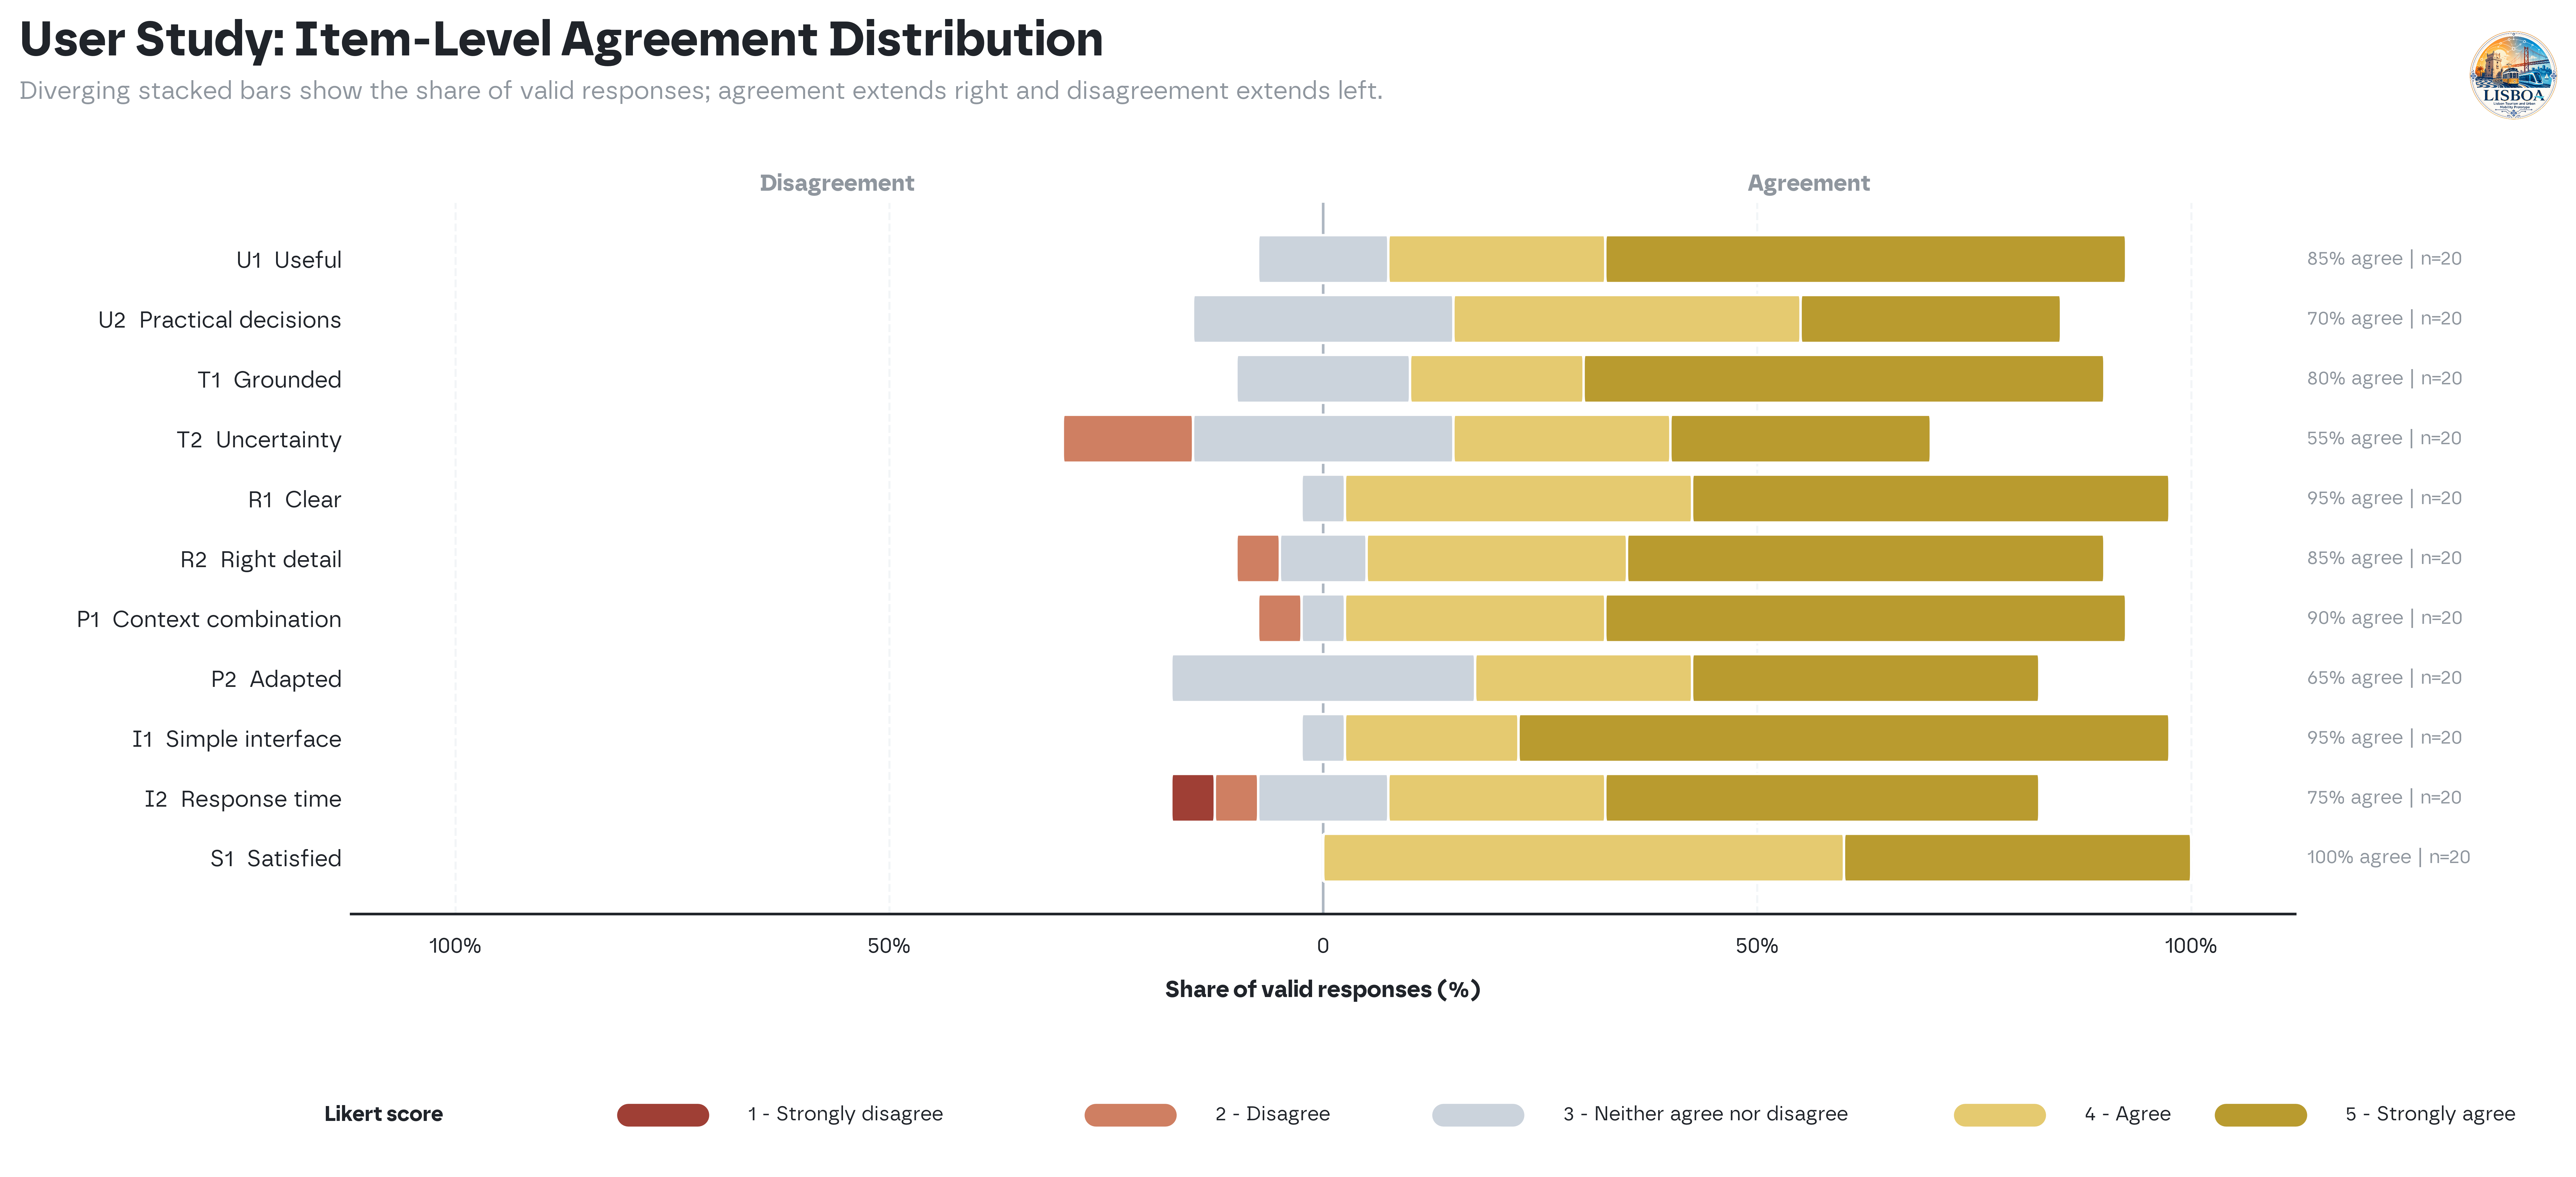

In [6]:
# ===========================================================================
# Figure 2: thesis-ready Likert agreement distribution
# ===========================================================================
LIKERT_LEGEND_LABELS = {
    1: "1 - Strongly disagree",
    2: "2 - Disagree",
    3: "3 - Neither agree nor disagree",
    4: "4 - Agree",
    5: "5 - Strongly agree",
}


def build_likert_distribution(long_frame: pd.DataFrame) -> pd.DataFrame:
    """Build percentage distributions for stacked Likert bars."""
    counts = (
        long_frame.dropna(subset=["score"])
        .groupby(["dimension", "item_id", "short_label", "score"], as_index=False, observed=True)
        .agg(count=("participant_id", "count"))
    )
    base = pd.DataFrame(
        [
            {"dimension": row.dimension, "item_id": row.item_id, "short_label": row.short_label, "score": float(score)}
            for row in ITEM_METADATA.itertuples(index=False)
            for score in [1, 2, 3, 4, 5]
        ]
    )
    merged = base.merge(counts, on=["dimension", "item_id", "short_label", "score"], how="left")
    merged["count"] = merged["count"].fillna(0).astype(int)
    totals = merged.groupby("item_id")["count"].transform("sum").replace(0, np.nan)
    merged["percent"] = merged["count"] / totals * 100
    return merged


likert_distribution = build_likert_distribution(item_long)
fig, ax = plt.subplots(figsize=(14.2, 6.45), dpi=EXPORT_DPI, facecolor="white")
y_labels = [f"{row.item_id}  {row.short_label}" for row in ITEM_METADATA.itertuples(index=False)]
y_positions = np.arange(len(y_labels))

for y_index, item_id in enumerate(ITEM_METADATA["item_id"]):
    item_dist = likert_distribution[likert_distribution["item_id"] == item_id].set_index("score")["percent"].fillna(0)
    neutral = float(item_dist.get(3.0, 0.0))
    left = -neutral / 2
    ax.barh(y_index, neutral, left=left, color=LIKERT_PALETTE[3], edgecolor="white", linewidth=0.9, zorder=2)

    neg_left = left
    for score in [2.0, 1.0]:
        width = float(item_dist.get(score, 0.0))
        neg_left -= width
        ax.barh(y_index, width, left=neg_left, color=LIKERT_PALETTE[int(score)], edgecolor="white", linewidth=0.9, zorder=2)

    pos_left = left + neutral
    for score in [4.0, 5.0]:
        width = float(item_dist.get(score, 0.0))
        ax.barh(y_index, width, left=pos_left, color=LIKERT_PALETTE[int(score)], edgecolor="white", linewidth=0.9, zorder=2)
        pos_left += width

    total = int(likert_distribution.loc[likert_distribution["item_id"] == item_id, "count"].sum())
    agreement = float(item_dist.get(4.0, 0.0) + item_dist.get(5.0, 0.0))
    ax.text(
        1.006,
        y_index,
        f"{agreement:.0f}% agree | n={total}",
        transform=ax.get_yaxis_transform(),
        va="center",
        ha="left",
        fontsize=7.4,
        color=NEUTRAL_GREY,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.92, "pad": 0.6},
        clip_on=False,
        zorder=7,
    )

round_bar_patches(ax, rounding_fraction=0.18)
ax.axvline(0, color=ZERO_LINE_GREY, linewidth=1.0, zorder=1)
ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, fontsize=8.6)
ax.invert_yaxis()
ax.set_xlim(-112, 112)
ax.set_xticks([-100, -50, 0, 50, 100])
ax.set_xticklabels(["100%", "50%", "0", "50%", "100%"], fontsize=8.4)
style_axis(ax, "", "", "", show_y_grid=False, show_x_grid=True)
ax.set_xlabel("Share of valid responses (%)", fontsize=8.8, fontweight="bold", labelpad=8)
ax.tick_params(axis="y", labelsize=8.6, length=0)
ax.tick_params(axis="x", labelsize=8.4)
ax.text(0.25, 1.010, "Disagreement", transform=ax.transAxes, fontsize=8.8, fontweight="bold", color=NEUTRAL_GREY, ha="center", va="bottom")
ax.text(0.75, 1.010, "Agreement", transform=ax.transAxes, fontsize=8.8, fontweight="bold", color=NEUTRAL_GREY, ha="center", va="bottom")

legend_axis = fig.add_axes([0.155, 0.026, 0.805, 0.070])
legend_axis.set_axis_off()
legend_axis.set_xlim(0, 1)
legend_axis.set_ylim(0, 1)
legend_axis.text(0.000, 0.50, "Likert score", ha="left", va="center", fontsize=8.0, fontweight="bold", color=DARK_GREY, transform=legend_axis.transAxes)
legend_positions = {1: 0.140, 2: 0.355, 3: 0.515, 4: 0.755, 5: 0.875}
for score, x_position in legend_positions.items():
    legend_axis.plot(
        [x_position, x_position + 0.032],
        [0.50, 0.50],
        color=LIKERT_PALETTE[score],
        linewidth=8.6,
        solid_capstyle="round",
        transform=legend_axis.transAxes,
        clip_on=False,
    )
    legend_axis.text(
        x_position + 0.055,
        0.50,
        LIKERT_LEGEND_LABELS[score],
        ha="left",
        va="center",
        fontsize=7.6,
        color=DARK_GREY,
        transform=legend_axis.transAxes,
    )

_subtitle_base = "Diverging stacked bars show the share of valid responses; agreement extends right and disagreement extends left."
if analysis_mode == "synthetic_preview":
    _subtitle_base += " Synthetic preview, not empirical findings."
add_figure_header(fig, "User Study: Item-Level Agreement Distribution", _subtitle_base)
add_corner_logo(fig)
fig.subplots_adjust(left=0.165, bottom=0.225, right=0.885, top=0.805)
save_figure("user_study_likert_distribution", fig)
plt.show()

Exported: eval\results\figures\user_study_context_and_tasks.svg
Exported: eval\results\figures\user_study_context_and_tasks.png


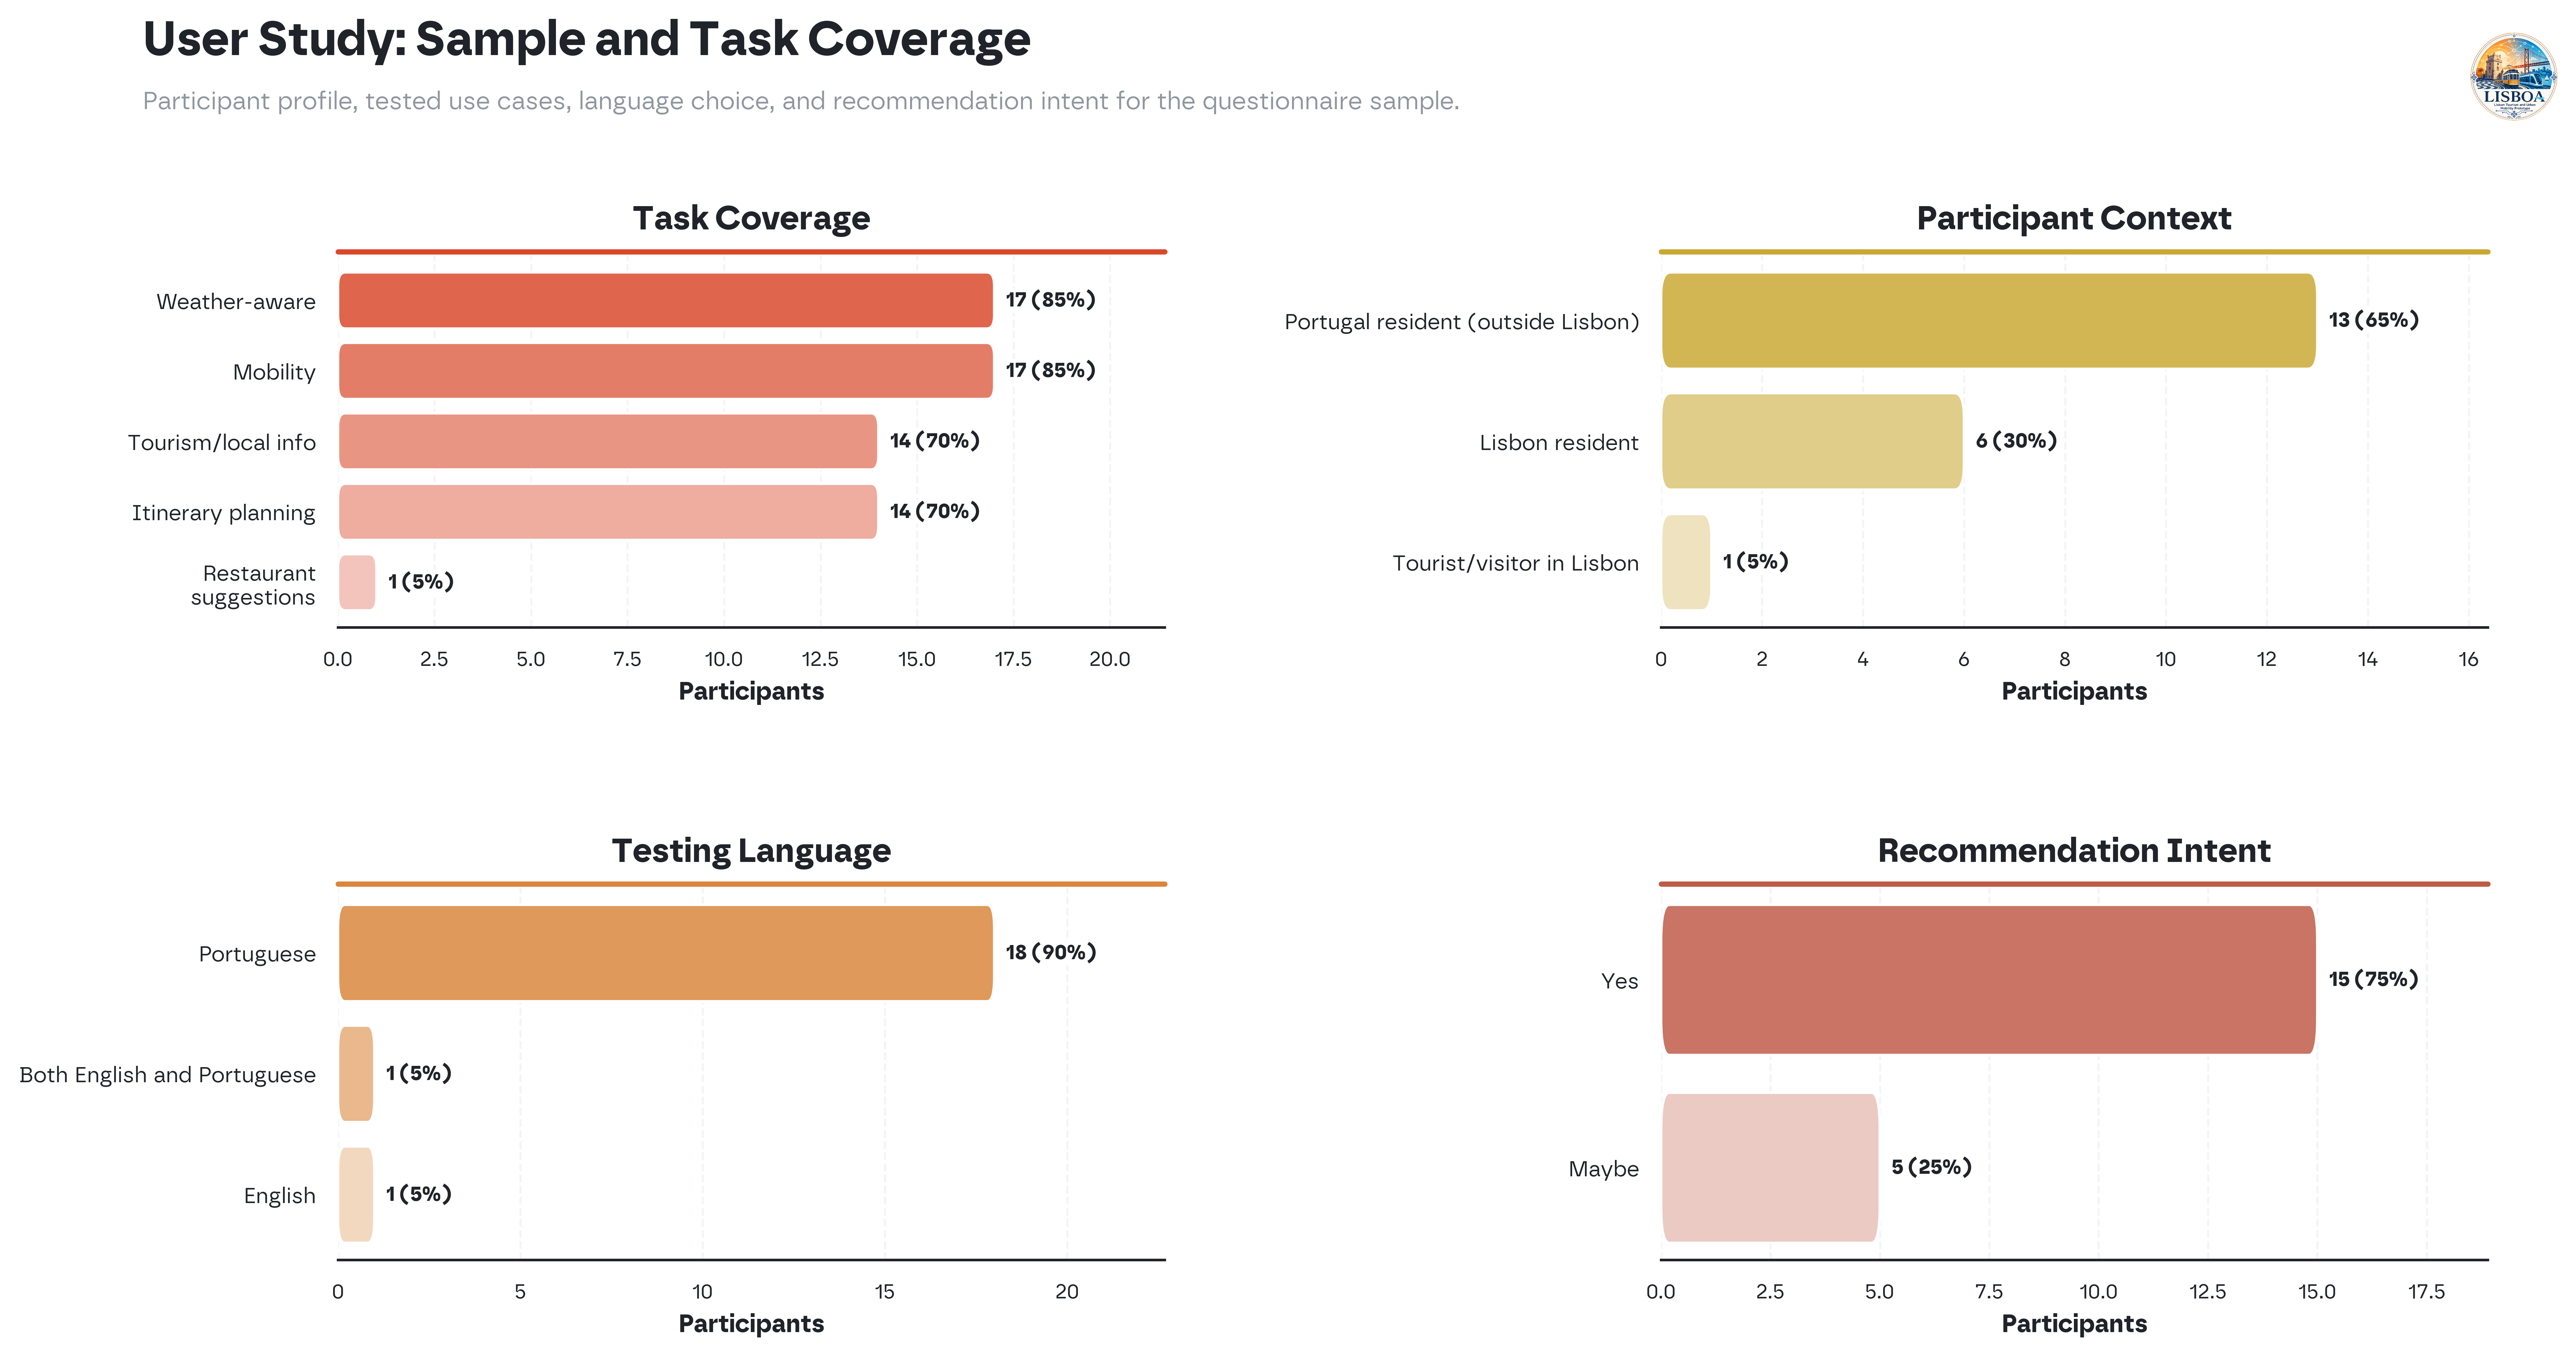

### Participant and testing summary

,Metric,Value
0,Participants,20
1,Median completion time (minutes),10.7
2,Participants completing four or more tasks,12
3,Recommendation yes/maybe rate,100.0%


In [7]:

# ===========================================================================
# Figure 3: thesis-ready sample and task coverage dashboard
# ===========================================================================
def count_series_values(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    """Count non-empty categorical values in a column."""
    series = frame[column].replace("", np.nan).dropna()
    return series.value_counts().rename_axis(column).reset_index(name="count")


task_counts = Counter(task for tasks in analysis_df["tasks_completed"] for task in tasks)
task_summary = pd.DataFrame([{"Task": task, "Participants": count} for task, count in task_counts.items()]).sort_values("Participants", ascending=True)
context_summary = count_series_values(analysis_df, "participant_type").sort_values("count", ascending=True)
context_summary["participant_type"] = context_summary["participant_type"].replace(
    {
        "Resident in Portugal, but not in Lisbon": "Portugal resident (outside Lisbon)",
        "Prospective tourist or visitor planning a Lisbon trip": "Planning a Lisbon trip",
        "Tourist or visitor currently in Lisbon": "Tourist/visitor in Lisbon",
    }
)
language_summary = count_series_values(analysis_df, "testing_language").sort_values("count", ascending=True)
recommend_summary = count_series_values(analysis_df, "recommend").sort_values("count", ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(13.6, 7.6), dpi=EXPORT_DPI, facecolor="white")
plot_specs = [
    (axes[0, 0], task_summary, "Task", "Participants", "Task Coverage", 20),
    (axes[0, 1], context_summary, "participant_type", "count", "Participant Context", 36),
    (axes[1, 0], language_summary, "testing_language", "count", "Testing Language", 32),
    (axes[1, 1], recommend_summary, "recommend", "count", "Recommendation Intent", 22),
]

for panel_index, (axis, frame, label_column, value_column, title, wrap_width) in enumerate(plot_specs):
    if frame.empty:
        axis.text(0.5, 0.5, "No data", transform=axis.transAxes, ha="center", va="center", color=NEUTRAL_GREY)
        axis.set_axis_off()
        continue
    frame = frame.copy()
    frame["wrapped_label"] = wrap_labels(frame[label_column].tolist(), width=wrap_width)
    base_color = PANEL_ACCENTS[panel_index % len(PANEL_ACCENTS)]
    colors = sequential_panel_colors(base_color, len(frame))
    axis.barh(frame["wrapped_label"], frame[value_column], color=colors, edgecolor="white", linewidth=1.0, zorder=3)
    label_horizontal_bars(axis, offset=max(frame[value_column].max() * 0.018, 0.10), total=len(analysis_df), outside=False)
    round_bar_patches(axis, rounding_fraction=0.24)
    axis.add_line(Line2D([0.0, 1.0], [1.010, 1.010], transform=axis.transAxes, color=base_color, linewidth=2.0, clip_on=False))
    style_axis(
        axis,
        title,
        "Participants",
        "",
        x_limits=(0, max(frame[value_column].max() * 1.26, 1.8)),
        show_y_grid=False,
        show_x_grid=True,
    )
    axis.tick_params(axis="both", labelsize=8.3)

_subtitle_base = "Participant profile, tested use cases, language choice, and recommendation intent for the questionnaire sample."
if analysis_mode == "synthetic_preview":
    _subtitle_base += " - Synthetic preview, not empirical findings."
add_figure_header(fig, "User Study: Sample and Task Coverage", _subtitle_base)
add_corner_logo(fig)
fig.subplots_adjust(left=0.118, bottom=0.090, right=0.955, top=0.790, hspace=0.70, wspace=0.60)
save_figure("user_study_context_and_tasks", fig)
plt.show()

context_table = pd.DataFrame(
    [
        {"Metric": "Participants", "Value": len(analysis_df)},
        {"Metric": "Median completion time (minutes)", "Value": round(float(analysis_df["duration_minutes"].median()), 1)},
        {"Metric": "Participants completing four or more tasks", "Value": int((analysis_df["task_count"] >= 4).sum())},
        {"Metric": "Recommendation yes/maybe rate", "Value": format_percent(analysis_df["recommend"].str.lower().isin(["yes", "maybe"]).mean())},
    ]
)
display(Markdown("### Participant and testing summary"))
display(context_table)


## **Reliability and exploratory associations**

Internal-consistency and correlation diagnostics are included as exploratory checks. With the planned sample size, these results should be read as signals for interpretation rather than inferential evidence.

### Internal-consistency diagnostics

,Scale,Items,Complete n,Cronbach alpha,Interpretation
0,Usefulness,U1; U2,20,0.822,Exploratory only
1,Trust,T1; T2,20,0.649,Exploratory only
2,Response Quality,R1; R2,20,0.676,Exploratory only
3,Personalization,P1; P2,20,0.702,Exploratory only
4,Interface,I1; I2,20,-0.051,Exploratory only
5,All perception items,U1; U2; T1; T2; R1; R2; P1; P2; I1; I2; S1,20,0.856,Exploratory only


### Spearman correlation matrix

,familiarity_lisbon,familiarity_ai,task_count,duration_minutes,Usefulness,Trust,Response Quality,Personalization,Interface,Overall Satisfaction
familiarity_lisbon,1.00,0.58,-0.04,-0.08,-0.17,0.12,-0.28,0.01,0.19,-0.07
familiarity_ai,0.58,1.00,0.07,-0.30,-0.02,0.22,0.08,0.26,-0.06,-0.05
task_count,-0.04,0.07,1.00,0.58,0.14,0.69,0.26,0.36,0.20,0.32
duration_minutes,-0.08,-0.30,0.58,1.00,-0.25,0.17,-0.15,-0.20,0.04,-0.04
Usefulness,-0.17,-0.02,0.14,-0.25,1.00,0.54,0.65,0.59,0.36,0.72
Trust,0.12,0.22,0.69,0.17,0.54,1.00,0.62,0.76,0.28,0.60
Response Quality,-0.28,0.08,0.26,-0.15,0.65,0.62,1.00,0.74,0.14,0.52
Personalization,0.01,0.26,0.36,-0.20,0.59,0.76,0.74,1.00,0.30,0.41
Interface,0.19,-0.06,0.20,0.04,0.36,0.28,0.14,0.30,1.00,0.52
Overall Satisfaction,-0.07,-0.05,0.32,-0.04,0.72,0.60,0.52,0.41,0.52,1.00


Exported: eval\results\figures\user_study_exploratory_correlations.svg
Exported: eval\results\figures\user_study_exploratory_correlations.png


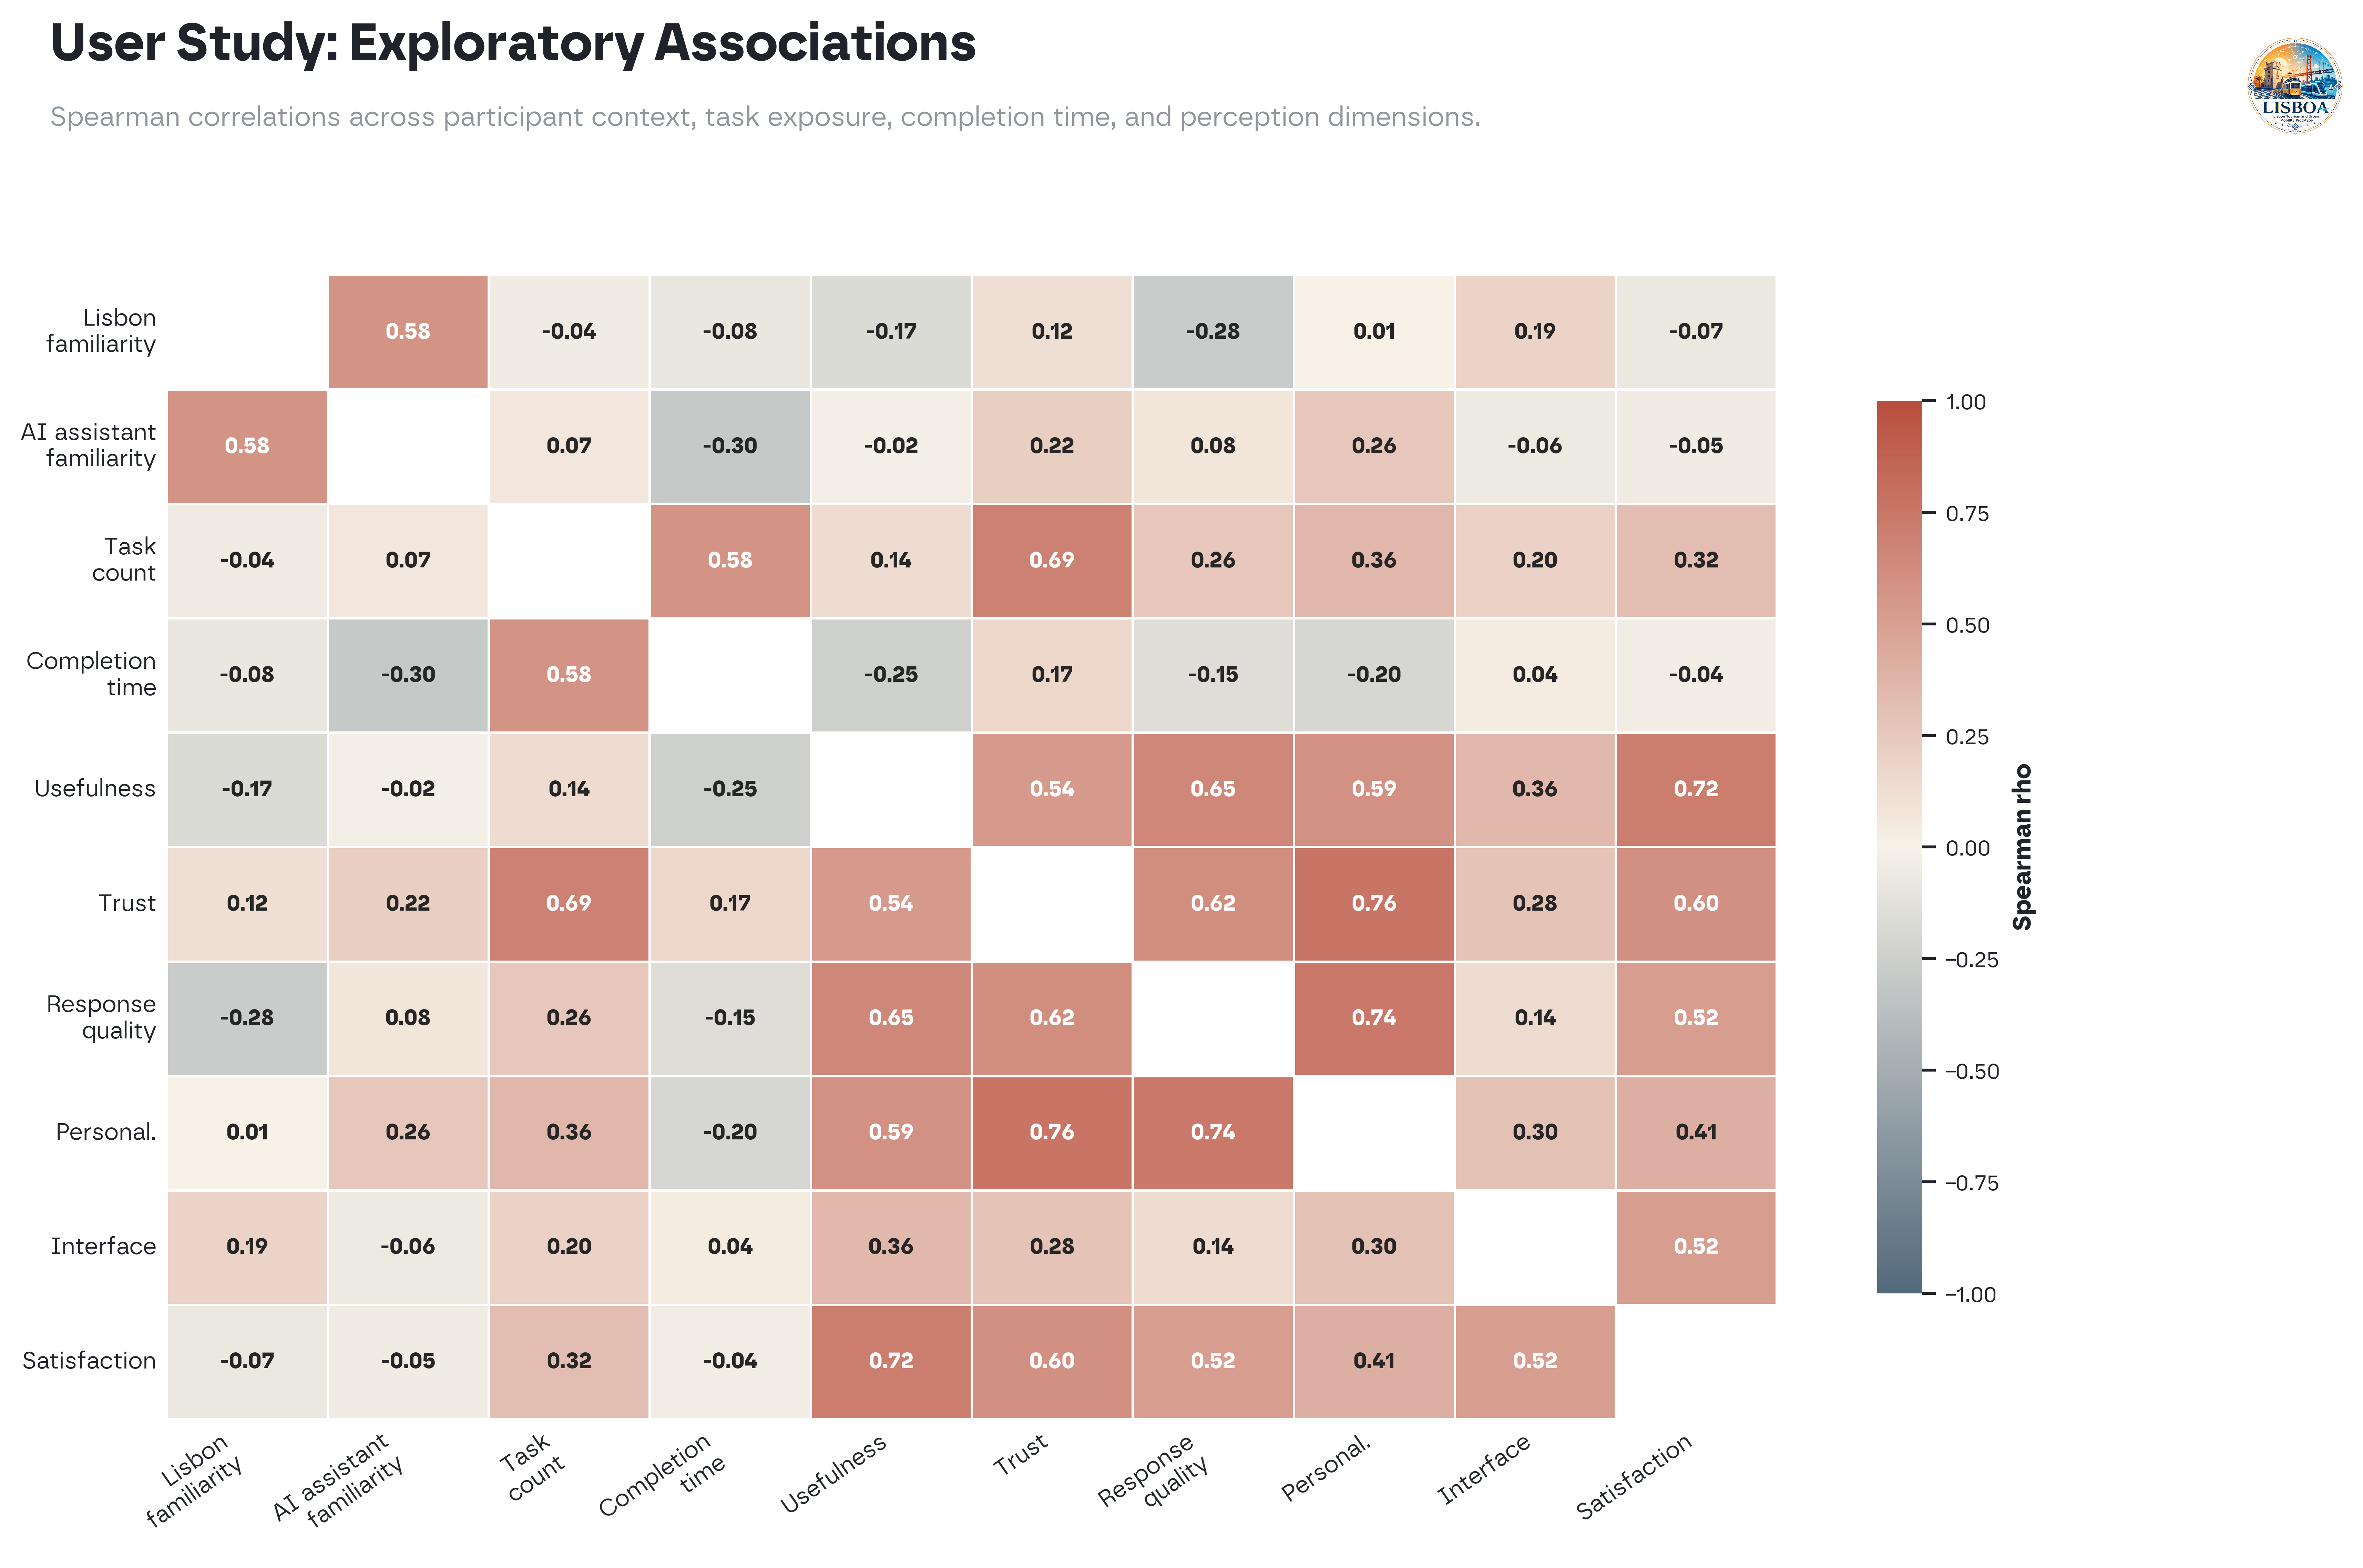

In [8]:

# ===========================================================================
# Reliability and exploratory associations
# ===========================================================================
def cronbach_alpha(frame: pd.DataFrame) -> float:
    """Compute Cronbach's alpha for complete rows in a multi-item score frame."""
    clean = frame.apply(pd.to_numeric, errors="coerce").dropna(axis=0, how="any")
    if clean.shape[0] < 3 or clean.shape[1] < 2:
        return np.nan
    item_variances = clean.var(axis=0, ddof=1)
    total_variance = clean.sum(axis=1).var(ddof=1)
    if total_variance == 0 or pd.isna(total_variance):
        return np.nan
    item_count = clean.shape[1]
    return float(item_count / (item_count - 1) * (1 - item_variances.sum() / total_variance))


reliability_rows = []
for dimension, items in DIMENSION_ITEMS.items():
    if len(items) >= 2:
        reliability_rows.append(
            {
                "Scale": dimension,
                "Items": "; ".join(items),
                "Complete n": int(analysis_df[items].dropna(axis=0, how="any").shape[0]),
                "Cronbach alpha": cronbach_alpha(analysis_df[items]),
                "Interpretation": "Exploratory only" if analysis_mode == "real" else "Synthetic preview only",
            }
        )
reliability_rows.append(
    {
        "Scale": "All perception items",
        "Items": "; ".join(ITEM_IDS),
        "Complete n": int(analysis_df[ITEM_IDS].dropna(axis=0, how="any").shape[0]),
        "Cronbach alpha": cronbach_alpha(analysis_df[ITEM_IDS]),
        "Interpretation": "Exploratory only" if analysis_mode == "real" else "Synthetic preview only",
    }
)
reliability_table = pd.DataFrame(reliability_rows)
display(Markdown("### Internal-consistency diagnostics"))
display_styled_table(
    reliability_table,
    caption="Cronbach alpha is reported only as a diagnostic because the planned sample is small.",
    gradient_subset=["Cronbach alpha"],
    precision=3,
    vmin=0,
    vmax=1,
)

wide_dimensions = participant_dimension_scores.pivot_table(index="participant_id", columns="dimension", values="dimension_score", aggfunc="first", observed=False).reset_index()
correlation_input = analysis_df[["participant_id", "familiarity_lisbon", "familiarity_ai", "task_count", "duration_minutes"]].merge(wide_dimensions, on="participant_id", how="left")
correlation_columns = ["familiarity_lisbon", "familiarity_ai", "task_count", "duration_minutes", "Usefulness", "Trust", "Response Quality", "Personalization", "Interface", "Overall Satisfaction"]
correlation_matrix = correlation_input[correlation_columns].corr(method="spearman", min_periods=3)
correlation_labels = {
    "familiarity_lisbon": "Lisbon\nfamiliarity",
    "familiarity_ai": "AI assistant\nfamiliarity",
    "task_count": "Task\ncount",
    "duration_minutes": "Completion\ntime",
    "Usefulness": "Usefulness",
    "Trust": "Trust",
    "Response Quality": "Response\nquality",
    "Personalization": "Personal.",
    "Interface": "Interface",
    "Overall Satisfaction": "Satisfaction",
}
display(Markdown("### Spearman correlation matrix"))
display(correlation_matrix.round(2))

fig, ax = plt.subplots(figsize=(11.8, 8.2), dpi=EXPORT_DPI, facecolor="white")
sns.heatmap(
    correlation_matrix,
    ax=ax,
    mask=np.eye(correlation_matrix.shape[0], dtype=bool),
    cmap=CORRELATION_CMAP,
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "", "shrink": 0.78},
    annot_kws={"fontsize": 8.2, "fontweight": "bold"},
)
ax.set_xticklabels([correlation_labels.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()], rotation=35, ha="right")
ax.set_yticklabels([correlation_labels.get(label.get_text(), label.get_text()) for label in ax.get_yticklabels()], rotation=0)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="both", labelsize=8.2, length=0)
colorbar = ax.collections[0].colorbar
if colorbar is not None:
    colorbar.ax.tick_params(labelsize=8.0)
    colorbar.set_label("Spearman rho", fontsize=8.8, fontweight="bold")
_subtitle_base = "Spearman correlations across participant context, task exposure, completion time, and perception dimensions."
if analysis_mode == "synthetic_preview":
    _subtitle_base += " - Synthetic preview, not empirical findings."
add_figure_header(fig, "User Study: Exploratory Associations", _subtitle_base)
add_corner_logo(fig)
fig.subplots_adjust(left=0.090, bottom=0.130, right=0.915, top=0.805)
save_figure("user_study_exploratory_correlations", fig)
plt.show()


## **Qualitative feedback analysis**

This section codes open-text responses into transparent first-pass themes. The counts help identify repeated perceived strengths, observed issues, and improvement requests, but they should be checked against the original excerpts before drawing final conclusions.

### Qualitative theme counts

,feedback_type,theme,participants
0,Helpful aspects,Interface or language,9
1,Helpful aspects,Itinerary structure,6
4,Helpful aspects,Transport guidance,6
3,Helpful aspects,Other,5
2,Helpful aspects,Local grounding,1
5,Helpful aspects,Weather-aware planning,1
10,Improvement requests,Other,9
9,Improvement requests,Map and booking links,7
12,Improvement requests,Route detail,5
8,Improvement requests,Itinerary ordering,2


Exported: eval\results\figures\user_study_qualitative_themes.svg
Exported: eval\results\figures\user_study_qualitative_themes.png


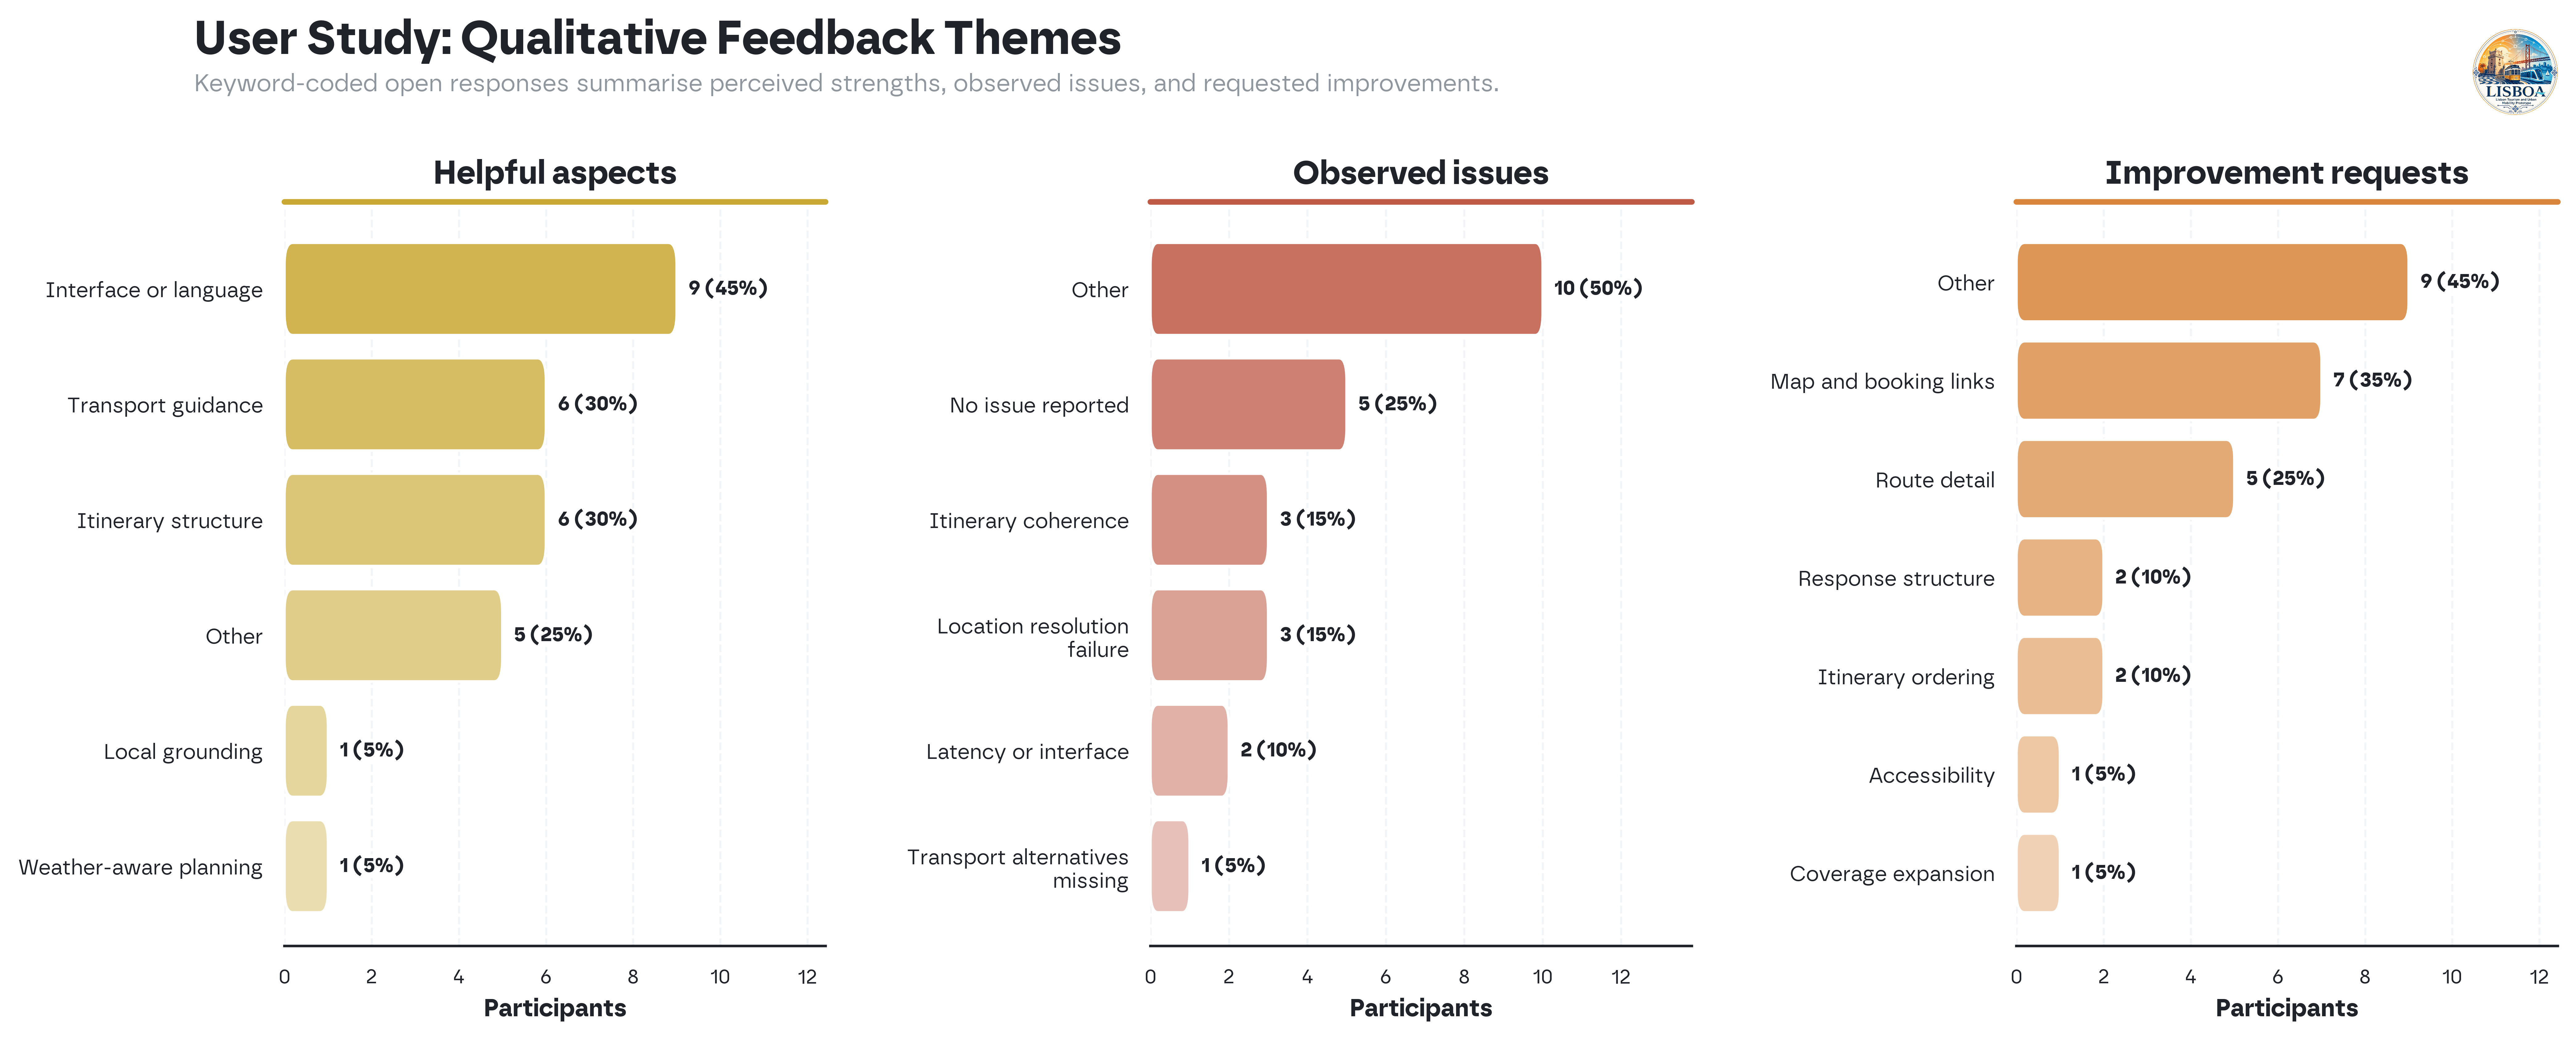

### Example excerpts for qualitative interpretation

,feedback_type,theme,text
0,Helpful aspects,Transport guidance,The most helpful part is the transport guidanc...
1,Observed issues,Transport alternatives missing,"Yes, for example if I ask to go from Rossio to..."
2,Improvement requests,Route detail,The itenerary structure should be more clear a...
3,Helpful aspects,Other,.
4,Observed issues,Other,.
5,Improvement requests,Other,.
6,Helpful aspects,Other,....
7,Observed issues,Other,....
8,Improvement requests,Other,...
9,Helpful aspects,Transport guidance,"A aplicação LISBOA, permitiu-me planear uma vi..."


In [9]:

# ===========================================================================
# Qualitative coding and thesis-ready theme plots
# ===========================================================================
THEME_RULES = {
    "helpful_text": {
        "Transport guidance": ["transport", "mobility", "route", "stop", "station", "schedule", "operator"],
        "Weather-aware planning": ["weather", "rain", "forecast", "outdoor"],
        "Itinerary structure": ["itinerary", "plan", "ordered", "timing", "structure"],
        "Local grounding": ["local", "lisbon", "source", "ground", "specific", "context"],
        "Interface or language": ["interface", "language", "bilingual", "format", "easy"],
    },
    "issue_text": {
        "Transport alternatives missing": ["alternative", "728", "15", "walk", "route", "transport"],
        "Location resolution failure": ["location", "place", "lesser", "famous", "business", "address", "gato", "papagaios"],
        "Itinerary coherence": ["itinerary", "coherent", "ordering", "multi stop", "stops", "geographic"],
        "Uncertainty or coverage": ["uncertain", "missing", "coverage", "unavailable", "incomplete"],
        "Latency or interface": ["slow", "time", "latency", "interface"],
    },
    "improve_text": {
        "Route detail": ["transport", "station", "duration", "schedule", "stop", "route"],
        "Itinerary ordering": ["order", "after", "previous", "proximity", "itinerary", "stops"],
        "Coverage expansion": ["sources", "restaurants", "business", "events", "coverage"],
        "Map and booking links": ["map", "maps", "booking", "links"],
        "Response structure": ["structure", "clear", "organized", "shorter", "sections"],
        "Accessibility": ["accessibility", "accessible", "wheelchair"],
    },
}


def code_themes(text: str, rules: dict[str, list[str]]) -> list[str]:
    """Assign qualitative themes using transparent keyword rules."""
    normalized = normalise_text(text)
    themes = [theme for theme, keywords in rules.items() if any(normalise_text(keyword) in normalized for keyword in keywords)]
    if themes:
        return themes
    return ["No issue reported"] if "no" in normalized and len(normalized) < 40 else ["Other"]


qualitative_records = []
for _, row in analysis_df.iterrows():
    for field_name, label in [("helpful_text", "Helpful aspects"), ("issue_text", "Observed issues"), ("improve_text", "Improvement requests")]:
        text = row.get(field_name, "")
        if not text:
            continue
        for theme in code_themes(text, THEME_RULES[field_name]):
            qualitative_records.append({"participant_id": row["participant_id"], "feedback_type": label, "theme": theme, "text": text})

qualitative_codes = pd.DataFrame(qualitative_records)
qualitative_theme_counts = (
    qualitative_codes.groupby(["feedback_type", "theme"], as_index=False)
    .agg(participants=("participant_id", "nunique"))
    .sort_values(["feedback_type", "participants"], ascending=[True, False])
)
display(Markdown("### Qualitative theme counts"))
display(qualitative_theme_counts)

fig, axes = plt.subplots(1, 3, figsize=(13.6, 5.9), dpi=EXPORT_DPI, facecolor="white")
feedback_specs = [
    ("Helpful aspects", QUALITATIVE_ACCENTS["Helpful aspects"]),
    ("Observed issues", QUALITATIVE_ACCENTS["Observed issues"]),
    ("Improvement requests", QUALITATIVE_ACCENTS["Improvement requests"]),
]
for axis, (feedback_type, color) in zip(axes, feedback_specs):
    frame = qualitative_theme_counts[qualitative_theme_counts["feedback_type"] == feedback_type].sort_values("participants", ascending=True).copy()
    if frame.empty:
        axis.text(0.5, 0.5, "No coded feedback", transform=axis.transAxes, ha="center", va="center", color=NEUTRAL_GREY)
        axis.set_axis_off()
        continue
    frame["theme_wrapped"] = wrap_labels(frame["theme"].tolist(), width=24)
    colors = sequential_panel_colors(color, len(frame), min_white=0.14, max_white=0.62)
    axis.barh(frame["theme_wrapped"], frame["participants"], color=colors, edgecolor="white", linewidth=1.0, zorder=3)
    label_horizontal_bars(
        axis,
        offset=max(frame["participants"].max() * 0.030, 0.12),
        total=len(analysis_df),
        outside=False,
    )
    round_bar_patches(axis, rounding_fraction=0.24)
    axis.add_line(Line2D([0.0, 1.0], [1.010, 1.010], transform=axis.transAxes, color=color, linewidth=2.2, clip_on=False))
    style_axis(axis, feedback_type, "Participants", "", x_limits=(0, max(frame["participants"].max() * 1.38, 1.8)), show_y_grid=False, show_x_grid=True)
    axis.tick_params(axis="both", labelsize=8.2)

_subtitle_base = "Keyword-coded open responses summarise perceived strengths, observed issues, and requested improvements."
if analysis_mode == "synthetic_preview":
    _subtitle_base += " - Synthetic preview, not empirical findings."
add_figure_header(fig, "User Study: Qualitative Feedback Themes", _subtitle_base)
add_corner_logo(fig)
fig.subplots_adjust(left=0.078, bottom=0.105, right=0.982, top=0.780, wspace=0.60)
save_figure("user_study_qualitative_themes", fig)
plt.show()

sample_excerpts = (
    qualitative_codes.drop_duplicates(["feedback_type", "participant_id"])
    .groupby("feedback_type", group_keys=False)
    .head(4)[["feedback_type", "theme", "text"]]
    .reset_index(drop=True)
)
display(Markdown("### Example excerpts for qualitative interpretation"))
display(sample_excerpts)


## **Result interpretation and export**

The final section consolidates the generated analysis objects, exports reusable summary tables, and produces a concise descriptive sentence only when the underlying data are suitable for interpretation.

In [10]:
# ===========================================================================
# Result interpretation, export, and concise result sentence
# ===========================================================================
def build_user_study_result_sentence(summary: pd.DataFrame) -> str:
    """Generate a conservative one-sentence descriptive result from summaries."""
    lookup = summary.set_index("Dimension")
    strongest = str(lookup["Median"].astype(float).idxmax())
    weakest = str(lookup["Median"].astype(float).idxmin())
    overall = float(lookup.loc["Overall Satisfaction", "Median"])
    recommend_rate = analysis_df["recommend"].str.lower().isin(["yes", "maybe"]).mean()
    return (
        "The user study indicated generally positive perceived quality, "
        f"with median overall satisfaction of {overall:.2f}/5, strongest ratings for {strongest.lower()}, "
        f"and comparatively lower ratings for {weakest.lower()}; {100 * recommend_rate:.1f}% of respondents "
        "answered yes or maybe to recommending LISBOA."
    )


analysis_readiness = pd.DataFrame(
    [
        {"Analysis component": "Dimension summary table", "Required output": "Median, IQR, and n by user-study dimension", "Notebook object": "dimension_results_table", "Status": "preview only" if analysis_mode == "synthetic_preview" else "ready from real data"},
        {"Analysis component": "Concise result sentence", "Required output": "One descriptive, non-overclaiming result sentence", "Notebook object": "suggested_user_study_result_sentence", "Status": "preview only" if analysis_mode == "synthetic_preview" else "ready for critical editing"},
        {"Analysis component": "Qualitative themes", "Required output": "Theme counts and representative excerpts", "Notebook object": "qualitative_theme_counts; sample_excerpts", "Status": "preview only" if analysis_mode == "synthetic_preview" else "ready for manual interpretation"},
    ]
)
suggested_user_study_result_sentence = build_user_study_result_sentence(dimension_summary)
display(Markdown("### Analysis readiness checks"))
display(analysis_readiness)
display(Markdown("### Concise result sentence"))
if analysis_mode == "synthetic_preview":
    display(Markdown("**Preview only.** This sentence is generated from synthetic preview data and should not be interpreted as an empirical result.\n\n> " + suggested_user_study_result_sentence))
else:
    display(Markdown("> " + suggested_user_study_result_sentence))

if EXPORT_TABLES:
    dimension_results_table_path = USER_STUDY_OUTPUT_DIR / "user_study_dimension_results.md"
    dimension_summary_path = USER_STUDY_OUTPUT_DIR / "user_study_dimension_summary.csv"
    item_summary_path = USER_STUDY_OUTPUT_DIR / "user_study_item_summary.csv"
    qualitative_counts_path = USER_STUDY_OUTPUT_DIR / "user_study_qualitative_theme_counts.csv"
    dimension_results_table_path.write_text(dimension_results_markdown + "\n", encoding="utf-8")
    dimension_summary.to_csv(dimension_summary_path, index=False)
    item_summary.to_csv(item_summary_path, index=False)
    qualitative_theme_counts.to_csv(qualitative_counts_path, index=False)
    print("Exported user-study tables:")
    print(f" - {dimension_results_table_path.relative_to(PROJECT_ROOT)}")
    print(f" - {dimension_summary_path.relative_to(PROJECT_ROOT)}")
    print(f" - {item_summary_path.relative_to(PROJECT_ROOT)}")
    print(f" - {qualitative_counts_path.relative_to(PROJECT_ROOT)}")
else:
    print("Table export is disabled. Set EXPORT_TABLES = True in the setup cell to export markdown/CSV summaries.")


### Analysis readiness checks

,Analysis component,Required output,Notebook object,Status
0,Dimension summary table,"Median, IQR, and n by user-study dimension",dimension_results_table,ready from real data
1,Concise result sentence,"One descriptive, non-overclaiming result sentence",suggested_user_study_result_sentence,ready for critical editing
2,Qualitative themes,Theme counts and representative excerpts,qualitative_theme_counts; sample_excerpts,ready for manual interpretation


### Concise result sentence

> The user study indicated generally positive perceived quality, with median overall satisfaction of 4.00/5, strongest ratings for usefulness, and comparatively lower ratings for trust; 100.0% of respondents answered yes or maybe to recommending LISBOA.

Exported user-study tables:
 - eval\results\user_study\user_study_dimension_results.md
 - eval\results\user_study\user_study_dimension_summary.csv
 - eval\results\user_study\user_study_item_summary.csv
 - eval\results\user_study\user_study_qualitative_theme_counts.csv


## **Reporting notes**

- Treat the user study as **formative human-centred evidence**, not as proof of population-level acceptance.
- Keep **median and IQR** as the primary quantitative summaries because the instrument uses ordinal Likert items.
- Use means, correlations, and reliability diagnostics only as secondary checks. They are not strong inferential claims with the planned sample size.
- Connect qualitative issues to automated results carefully. For example, complaints about itinerary coherence or transport alternatives can contextualise lower robustness, but they do not by themselves quantify failure rates.
- When the real data are available, report one concise statement covering the strongest dimension, the weakest or most limited dimension, satisfaction, and recommendation intent.
- Do not report synthetic preview values as empirical findings. They exist only to validate that the notebook produces complete, readable, thesis-ready tables and figures.